# Loan Limit — Multi-Period Lifecycle Simulation

A customer-level lifecycle model that re-evaluates each account every `CAMPAIGN_INTERVAL_DAYS` days over a configurable simulation window.

Each campaign runs the same Monte Carlo → GBM Uptake → LP pipeline as the one-shot model, but adds:
- **Explicit Bernoulli acceptance draw** on `uptake_probability`
- **Actual term + outcome draws** (early / on-time / default) per extension
- **Feature update → re-score** after every outcome so credit state evolves over time

**Configurable parameters:** `SIMULATION_YEARS`, `CAMPAIGN_INTERVAL_DAYS`, `LIFECYCLE_MC_ITER`, `ONTIME_PAYMENT_BOOST`, `EARLY_PAYMENT_BOOST`, `DEFAULT_PAYMENT_PENALTY`

## 1. Imports & Configuration

In [1]:
# ── Standard library ─────────────────────────────────────────────────────────
import os, json, math, time, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Any, Optional

warnings.filterwarnings('ignore')

# ── Core ─────────────────────────────────────────────────────────────────────
import numpy  as np
import pandas as pd
from scipy.optimize    import linprog
from scipy.stats       import lognorm
from sklearn.cluster   import KMeans
from sklearn.preprocessing import StandardScaler

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (10, 5)})

# ── Macro API ─────────────────────────────────────────────────────────────────
try:
    from fredapi import Fred
    FRED_AVAILABLE = True
except ImportError:
    FRED_AVAILABLE = False

import requests

print("All imports OK")
print(f"  FRED API available: {FRED_AVAILABLE}")


All imports OK
  FRED API available: True


In [2]:
# ── Configuration (override via environment variables) ─────────────────────────
DATA_FILE               = Path(os.getenv('DATA_FILE',          'loan_limit_increases.csv'))
RESULTS_FILE            = os.getenv('RESULTS_FILE',            'lifecycle_results.csv')
CACHE_DIR               = Path('cache'); CACHE_DIR.mkdir(exist_ok=True)

NPV_DISCOUNT_RATE       = float(os.getenv('NPV_DISCOUNT_RATE',       '0.19'))
SIMULATION_ITERATIONS   = int(  os.getenv('SIMULATION_ITERATIONS',   '3500'))
MAX_PORTFOLIO_DEFAULT_RISK = float(os.getenv('MAX_PORTFOLIO_DEFAULT_RISK', '0.05'))
MAX_TOTAL_EXPOSURE      = float(os.getenv('MAX_TOTAL_EXPOSURE',      '500_000_000'))
MIN_DAYS_SINCE_LOAN     = int(  os.getenv('MIN_DAYS_SINCE_LOAN',     '60'))
LGD                     = float(os.getenv('LGD',                     '0.60'))
PROFIT_PER_EXTENSION    = float(os.getenv('PROFIT_PER_EXTENSION',    '40.0'))
BATCH_SIZE              = int(  os.getenv('BATCH_SIZE',               '5000'))
HORIZON_DAYS            = int(  os.getenv('HORIZON_DAYS',             '365'))

CREDIT_STATES = ['Excellent', 'Good', 'Fair', 'Poor']

# ── Term extension parameters by credit state ──────────────────────────────────
# mean_days  : expected extension length (customer-specific factors shift this)
# std_days   : variability in extension length
# lambda_ann : annual default hazard rate (aligned with FDIC charge-off norms by tier)
# p_early    : probability of early repayment before term expires
TERM_PARAMS = {
    'Excellent': {'mean_days': 90, 'std_days': 12, 'lambda_ann': 0.015, 'p_early': 0.25},
    'Good':      {'mean_days': 75, 'std_days': 15, 'lambda_ann': 0.040, 'p_early': 0.20},
    'Fair':      {'mean_days': 60, 'std_days': 18, 'lambda_ann': 0.100, 'p_early': 0.12},
    'Poor':      {'mean_days': 45, 'std_days': 20, 'lambda_ann': 0.220, 'p_early': 0.05},
}

# ── Macro scenarios ────────────────────────────────────────────────────────────
MACRO_SCENARIOS = {
    'optimistic': {'gdp_growth': 3.5, 'unemployment': 3.5, 'fed_rate': 4.0, 'cpi': 2.5},
    'baseline':   {'gdp_growth': 2.5, 'unemployment': 4.0, 'fed_rate': 5.0, 'cpi': 3.5},
    'adverse':    {'gdp_growth': 0.5, 'unemployment': 5.5, 'fed_rate': 6.0, 'cpi': 5.0},
}

print(f"  Discount rate        : {NPV_DISCOUNT_RATE:.0%}")
print(f"  Simulation iterations: {SIMULATION_ITERATIONS:,}")
print(f"  Max portfolio risk   : {MAX_PORTFOLIO_DEFAULT_RISK:.0%}")
print(f"  Max total exposure   : ${MAX_TOTAL_EXPOSURE:,.0f}")
print(f"  Profit per extension : ${PROFIT_PER_EXTENSION:.0f}")
print(f"  LGD                  : {LGD:.0%}")

  Discount rate        : 19%
  Simulation iterations: 3,500
  Max portfolio risk   : 5%
  Max total exposure   : $500,000,000
  Profit per extension : $40
  LGD                  : 60%


## 2. Data Loading & Preprocessing

In [3]:
def load_and_preprocess_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df = df.rename(columns={
        'Customer ID':             'customer_id',
        'Initial Loan ($)':        'initial_loan',
        'Days Since Last Loan':    'days_since_last_loan',
        'On-time Payments (%)':    'on_time_payments_pct',
        'No. of Increases in 2023':'num_increases_2023',
        'Total Profit Contribution ($)': 'total_profit_contribution',
    })
    assert len(df) == 30_000, f"Expected 30,000 rows, got {len(df)}"
    assert df.isnull().sum().sum() == 0, "Missing values found"

    # Eligibility: >= 60 days since last disbursement + on-time payments
    df['eligible'] = (df['days_since_last_loan'] >= MIN_DAYS_SINCE_LOAN).astype(int)
    df['utilization_rate'] = np.clip(
        1.0 - df['days_since_last_loan'].clip(0, 365) / 365.0, 0.05, 0.95
    )

    # Normalise for credit scoring
    scaler = StandardScaler()
    num_cols = ['initial_loan','days_since_last_loan','on_time_payments_pct',
                'num_increases_2023','total_profit_contribution']
    df_scaled = df.copy()
    df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

    print(f"Loaded {len(df):,} customers")
    print(f"  Eligible (days >= {MIN_DAYS_SINCE_LOAN}): {df['eligible'].sum():,} ({df['eligible'].mean():.1%})")
    print(f"  Loan range: ${df['initial_loan'].min():,.0f} – ${df['initial_loan'].max():,.0f}")
    print(df[['initial_loan','days_since_last_loan','on_time_payments_pct',
              'num_increases_2023']].describe().round(2))
    return df

df_raw = load_and_preprocess_data(DATA_FILE)
df = df_raw.copy()

Loaded 30,000 customers
  Eligible (days >= 60): 25,068 (83.6%)
  Loan range: $500 – $4,999
       initial_loan  days_since_last_loan  on_time_payments_pct  \
count      30000.00              30000.00              30000.00   
mean        2752.53                181.48                 90.02   
std         1293.03                105.07                  5.75   
min          500.00                  0.00                 80.00   
25%         1630.00                 90.00                 85.08   
50%         2761.00                182.00                 90.05   
75%         3866.00                272.00                 95.01   
max         4999.00                364.00                100.00   

       num_increases_2023  
count            30000.00  
mean                 2.24  
std                  2.08  
min                  0.00  
25%                  0.00  
50%                  3.00  
75%                  4.00  
max                  5.00  


## 3. Credit State Classification

In [4]:
def classify_credit_states(df: pd.DataFrame) -> pd.DataFrame:
    """
    Two-step classification: Borda-count composite → K-Means on RISK RANK.

    Step 1: Ordinal Borda-count credit_score (FICO-aligned weights):
      35% payment history | 30% credit discipline | 20% recency | 15% value

    Step 2: risk_rank = 1 − credit_score  (0 = safest, 1 = riskiest)
            K-Means (k=4) on risk_rank → data-driven tier boundaries.
            Lowest centroid = Excellent, highest = Poor.

    Using risk_rank (not credit_score) for clustering aligns the K-Means axis
    with the quantity being managed (default risk), not its inverse.
    A comparison of percentile vs K-Means boundaries is printed for audit.
    """
    df = df.copy()
    n  = len(df)

    # ── Step 1: Borda-count credit score ──────────────────────────────────────
    r_pay  = df['on_time_payments_pct'].rank(pct=True)
    r_disc = (1 - df['num_increases_2023'].rank(pct=True))
    r_rec  = (1 - df['days_since_last_loan'].rank(pct=True))
    r_val  = df['total_profit_contribution'].rank(pct=True)
    df['credit_score'] = r_pay * 0.35 + r_disc * 0.30 + r_rec * 0.20 + r_val * 0.15

    # ── Step 2: risk_rank = 1 − credit_score ──────────────────────────────────
    df['risk_rank'] = 1.0 - df['credit_score']

    # ── Percentile thresholds (25/50/75 on risk_rank) — comparison baseline ──
    q25, q50, q75 = df['risk_rank'].quantile([0.25, 0.50, 0.75]).values

    def pct_state(rr):
        if rr <= q25: return 'Excellent'
        if rr <= q50: return 'Good'
        if rr <= q75: return 'Fair'
        return 'Poor'
    states_pct = df['risk_rank'].apply(pct_state)

    # ── K-Means on risk_rank ──────────────────────────────────────────────────
    km = KMeans(n_clusters=4, random_state=42, n_init=20)
    km.fit(df[['risk_rank']])
    centroids = km.cluster_centers_.flatten()
    # Ascending centroid order → Excellent (safest) to Poor (riskiest)
    order     = np.argsort(centroids)
    label_map = {old: CREDIT_STATES[new] for new, old in enumerate(order)}
    states_km = pd.Series([label_map[c] for c in km.labels_], index=df.index)

    # ── Comparison table ──────────────────────────────────────────────────────
    print("=" * 68)
    print("  CLASSIFICATION: Percentile (25/50/75) vs K-Means on risk_rank")
    print("=" * 68)
    print(f"  {'State':<12} {'Percentile':>14} {'K-Means':>14} {'Δ':>8}")
    print(f"  {'-'*52}")
    for state in CREDIT_STATES:
        p = (states_pct == state).sum()
        k = (states_km  == state).sum()
        print(f"  {state:<12} {p:>7,} ({100*p/n:4.1f}%)  {k:>7,} ({100*k/n:4.1f}%)  "
              f"{'↑' if k>p else '↓' if k<p else '='}{abs(k-p):>5,}")
    diff = (states_pct != states_km).sum()
    print(f"  Customers re-assigned by K-Means: {diff:,} / {n:,} ({100*diff/n:.1f}%)")
    print("=" * 68)
    print("  → K-Means adopted as primary (data-driven boundaries on risk axis)")

    # ── Adopt K-Means ─────────────────────────────────────────────────────────
    df['credit_state'] = states_km.values

    # ── Within-state default risk: base × (0.5 + within_state_pctile) ─────────
    base = {'Excellent': 0.010, 'Good': 0.030, 'Fair': 0.080, 'Poor': 0.200}
    dr   = np.zeros(n)
    for state in CREDIT_STATES:
        mask = df['credit_state'] == state
        within = df.loc[mask, 'risk_rank'].rank(pct=True)
        dr[mask.values] = np.clip(base[state] * (0.5 + within), 0.001, 0.99)
    df['default_risk']    = dr
    df['high_risk_flag']  = (dr > 0.15).astype(int)
    df['risk_model']      = 'ordinal_risk_rank_kmeans'

    print("\nCredit state distribution (K-Means on risk_rank):")
    print(df['credit_state'].value_counts().reindex(CREDIT_STATES))
    print(f"\nDefault risk: mean={dr.mean():.3f}  min={dr.min():.3f}  max={dr.max():.3f}")
    return df

df = classify_credit_states(df)


  CLASSIFICATION: Percentile (25/50/75) vs K-Means on risk_rank
  State            Percentile        K-Means        Δ
  ----------------------------------------------------
  Excellent      7,500 (25.0%)    6,206 (20.7%)  ↓1,294
  Good           7,500 (25.0%)    9,267 (30.9%)  ↑1,767
  Fair           7,500 (25.0%)    9,089 (30.3%)  ↑1,589
  Poor           7,500 (25.0%)    5,438 (18.1%)  ↓2,062
  Customers re-assigned by K-Means: 3,829 / 30,000 (12.8%)
  → K-Means adopted as primary (data-driven boundaries on risk axis)

Credit state distribution (K-Means on risk_rank):
credit_state
Excellent    6206
Good         9267
Fair         9089
Poor         5438
Name: count, dtype: int64

Default risk: mean=0.072  min=0.005  max=0.300


## 4. Macro Data Enrichment

In [5]:
# ── FRED API Macro Data Fetching ─────────────────────────────────────────────
# Set your FRED API key as: export FRED_API_KEY="your_key_here"
# Get a free key at: https://fred.stlouisfed.org/docs/api/api_key.html
# If no key is set the function falls back to cached baseline defaults.

MACRO_CACHE_FILE = CACHE_DIR / 'macro_data_2023.json'


def fetch_macro_data(year: int = 2023) -> Dict[str, float]:
    """
    Fetch macroeconomic indicators from FRED API with caching and retry logic.

    Series fetched:
      GDPC1    — Real GDP (quarterly, pct change annualised)
      UNRATE   — Unemployment rate (monthly avg)
      FEDFUNDS — Federal Funds Rate (monthly avg)
      CPIAUCSL — CPI All Urban (YoY pct change)

    Returns dict with keys: gdp_growth, unemployment, fed_rate, cpi, inflation.
    Falls back to cached data, then to baseline defaults on API failure.
    """
    # 1. Try disk cache first
    if MACRO_CACHE_FILE.exists():
        with open(MACRO_CACHE_FILE) as f:
            cached = json.load(f)
        print(f"  Macro data loaded from cache ({MACRO_CACHE_FILE})")
        return cached

    # 2. Attempt FRED API (requires FRED_API_KEY env var)
    api_key = os.getenv('FRED_API_KEY', '')
    if FRED_AVAILABLE and api_key:
        for attempt in range(3):
            try:
                fred   = Fred(api_key=api_key)
                start  = f'{year}-01-01'
                end    = f'{year}-12-31'

                gdp   = fred.get_series('GDPC1',    start, end).pct_change().mean() * 100
                unemp = fred.get_series('UNRATE',   start, end).mean()
                fed   = fred.get_series('FEDFUNDS', start, end).mean()
                cpi   = fred.get_series('CPIAUCSL', start, end).pct_change(12).iloc[-1] * 100

                data = {
                    'gdp_growth':   round(float(gdp),   2),
                    'unemployment': round(float(unemp),  2),
                    'fed_rate':     round(float(fed),    2),
                    'cpi':          round(float(cpi),    2),
                    'inflation':    round(float(cpi),    2),
                }
                with open(MACRO_CACHE_FILE, 'w') as f:
                    json.dump(data, f, indent=2)
                print(f"  FRED API fetch successful (attempt {attempt + 1})")
                return data

            except Exception as e:
                wait = 2 ** attempt
                print(f"  FRED API attempt {attempt + 1} failed: {e}. Retrying in {wait}s …")
                time.sleep(wait)
    else:
        if not api_key:
            print("  FRED_API_KEY not set — skipping live fetch")
        if not FRED_AVAILABLE:
            print("  fredapi package not installed — run: pip install fredapi")

    # 3. Fall back to hardcoded baseline defaults (2023 actuals)
    print("  WARNING: Using baseline macro defaults")
    data = {
        'gdp_growth':   2.5,
        'unemployment': 4.0,
        'fed_rate':     5.0,
        'cpi':          3.5,
        'inflation':    3.5,
    }
    with open(MACRO_CACHE_FILE, 'w') as f:
        json.dump(data, f, indent=2)
    return data


def fetch_macro_scenarios() -> Dict[str, Dict[str, float]]:
    """
    Return macro data for all three scenarios.
    Scales the fetched/cached baseline proportionally using MACRO_SCENARIOS ratios.
    This ensures live FRED data flows into scenario analysis automatically.
    """
    base = fetch_macro_data()
    base_ref  = MACRO_SCENARIOS['baseline']   # reference ratios
    opt_ref   = MACRO_SCENARIOS['optimistic']
    adv_ref   = MACRO_SCENARIOS['adverse']

    def scale(ref_scenario):
        return {
            k: round(base[k] * ref_scenario[k] / base_ref[k], 3)
            if base_ref.get(k, 0) != 0 else base[k]
            for k in base
        }

    return {
        'optimistic': scale(opt_ref),
        'baseline':   dict(base),
        'adverse':    scale(adv_ref),
    }


def enrich_with_macro(df: pd.DataFrame, macro: Dict[str, float]) -> pd.DataFrame:
    """
    Adjust per-customer default risk and term parameters using macro conditions.

    Adjustment rules (calibrated to historical recession data):
      +1 pp unemployment above baseline (4%)  → +1 pp annual hazard rate
      +1 pp fed funds rate above baseline (5%) → +0.5 pp annual hazard rate
      +1 pp GDP growth above baseline (2.5%)   → +10 day extension term offered
    """
    df = df.copy()

    unemp_adj    = (macro.get('unemployment', 4.0) - 4.0) * 0.01
    rate_adj     = (macro.get('fed_rate',     5.0) - 5.0) * 0.005
    macro_risk_adj = 1.0 + unemp_adj + rate_adj

    df['default_risk'] = np.clip(df['default_risk'] * macro_risk_adj, 0.001, 0.99)

    gdp_adj = (macro.get('gdp_growth', 2.5) - 2.5) / 100.0
    df['term_adj_days'] = gdp_adj * 10

    # Store macro indicators as columns for downstream use
    df['macro_gdp_growth']   = macro.get('gdp_growth',   2.5)
    df['macro_unemployment'] = macro.get('unemployment', 4.0)
    df['macro_fed_rate']     = macro.get('fed_rate',     5.0)
    df['macro_cpi']          = macro.get('cpi',          3.5)

    print(f"  Macro risk multiplier : ×{macro_risk_adj:.3f}")
    print(f"  Term day adjustment   : {gdp_adj * 10:+.1f} days")
    return df


# ── Fetch and enrich ──────────────────────────────────────────────────────────
macro_data     = fetch_macro_data()
macro_scenarios = fetch_macro_scenarios()

print("\nMacroeconomic Indicators (Baseline):")
for k, v in macro_data.items():
    print(f"  {k:<20}: {v:.2f}")

df = enrich_with_macro(df, macro_data)
print(f"\nMacro enrichment complete  →  {df.shape[0]:,} customers enriched")
print(f"  Adjusted default risk: mean={df['default_risk'].mean():.4f}")


  Macro data loaded from cache (cache/macro_data_2023.json)
  Macro data loaded from cache (cache/macro_data_2023.json)

Macroeconomic Indicators (Baseline):
  gdp_growth          : 2.50
  unemployment        : 4.00
  fed_rate            : 5.00
  cpi                 : 3.50
  inflation           : 3.50
  Macro risk multiplier : ×1.000
  Term day adjustment   : +0.0 days

Macro enrichment complete  →  30,000 customers enriched
  Adjusted default risk: mean=0.0718


## 5. Helper Functions

The following three functions are used **inside `simulate_lifecycle()`** on each campaign's eligible customer subset. They are defined here but not executed standalone.

### 5a. GBM Uptake Forecast

In [6]:
# ── GBM Uptake Forecast ──────────────────────────────────────────────────────
#
# Uptake probability = P(customer accepts the term extension offer)
#
# Modelled using Geometric Brownian Motion (GBM), matching the claude-branch
# utilization forecasting approach:
#
#   U_T = μ_i · exp(−½σ²·dt + σ·dW)      dW ~ N(0, sqrt(dt))
#
# where μ_i = state base rate + macro drift + individual profit adjustment.
# GBM produces lognormal terminal values: positive, right-skewed, and bounded
# by clipping to [0.01, 0.99]. Volatility (σ) is higher for riskier states
# because their behaviour is less predictable.
#
# Scenario adjustments mirror the claude branch:
#   Optimistic: drift_adj = +0.02, vol_scale = 0.80  (higher uptake, less noise)
#   Baseline:   drift_adj =  0.00, vol_scale = 1.00
#   Adverse:    drift_adj = −0.03, vol_scale = 1.30  (lower uptake, more noise)

UPTAKE_PARAMS = {
    # state      mu     sigma   (mu = base uptake rate; sigma = GBM volatility)
    'Excellent': {'mu': 0.80, 'sigma': 0.10},
    'Good':      {'mu': 0.70, 'sigma': 0.12},
    'Fair':      {'mu': 0.55, 'sigma': 0.16},
    'Poor':      {'mu': 0.35, 'sigma': 0.20},
}

def forecast_uptake(
    df: pd.DataFrame,
    macro: Dict[str, float],
    n_scenarios: int = SIMULATION_ITERATIONS,
    scenario: str = 'baseline',
) -> pd.DataFrame:
    """
    GBM stochastic uptake model: P(customer accepts term extension offer).

    Uses Geometric Brownian Motion terminal values so uptake paths are
    lognormally distributed — positive, right-skewed, consistent with the
    claude-branch utilization forecasting methodology.

    Factors:
      - Credit state:    state-specific GBM mu (base rate) and sigma (volatility)
      - Macro scenario:  GDP/unemployment shift drift and volatility scaling
      - Individual:      profit-history rank adds ±5pp personalised drift
    """
    df = df.copy()
    rng = np.random.default_rng(42)

    # Scenario adjustments (mirrors claude branch forecast_utilization)
    scenario_adj = {
        'optimistic': {'drift_adj': +0.02, 'vol_scale': 0.80},
        'baseline':   {'drift_adj':  0.00, 'vol_scale': 1.00},
        'adverse':    {'drift_adj': -0.03, 'vol_scale': 1.30},
    }.get(scenario, {'drift_adj': 0.0, 'vol_scale': 1.0})

    # Additional macro adjustment from live macro data
    gdp_adj   = (macro.get('gdp_growth',   2.5) - 2.5) * 0.02
    unemp_adj = -(macro.get('unemployment', 4.0) - 4.0) * 0.03
    macro_drift = gdp_adj + unemp_adj + scenario_adj['drift_adj']
    vol_scale   = scenario_adj['vol_scale']

    uptake_rates = np.zeros(len(df))
    uptake_std   = np.zeros(len(df))

    dt = 1.0  # normalised time horizon (uptake is a point-in-time decision)

    for state in CREDIT_STATES:
        mask = df['credit_state'] == state
        if not mask.any():
            continue
        nc = mask.sum()

        params = UPTAKE_PARAMS[state]
        sigma  = params['sigma'] * vol_scale

        # Individual drift: profit rank shifts mu ±5pp around state base
        profit_rank = df.loc[mask, 'total_profit_contribution'].rank(pct=True)
        mu_i = np.clip(params['mu'] + macro_drift + profit_rank.values * 0.10 - 0.05,
                       0.05, 0.95)

        # GBM terminal value per customer per scenario
        # Shape: (n_scenarios, nc)
        dW     = rng.normal(0.0, np.sqrt(dt), (n_scenarios, nc))
        draws  = np.clip(
            mu_i[np.newaxis, :] * np.exp(-0.5 * sigma**2 * dt + sigma * dW),
            0.01, 0.99
        )

        cohort_mean = draws.mean(axis=0)   # per-customer mean across scenarios
        cohort_std  = draws.std(axis=0)

        uptake_rates[mask.values] = cohort_mean
        uptake_std  [mask.values] = cohort_std

    df['uptake_probability'] = np.clip(uptake_rates, 0.01, 0.99)
    df['uptake_std']         = uptake_std
    df['forecast_scenario']  = scenario

    print(f"GBM uptake forecast  (macro_drift={macro_drift:+.3f}, vol_scale={vol_scale:.2f}):")
    for state in CREDIT_STATES:
        mask = df['credit_state'] == state
        u = df.loc[mask, 'uptake_probability']
        print(f"  {state:<10}: mean={u.mean():.3f}  std={u.std():.3f}  "
              f"[{u.min():.3f}, {u.max():.3f}]")
    return df



### 5b. Monte Carlo Term Simulation

In [7]:
# ── Vectorised Monte Carlo — Term Extension Simulation ───────────────────────
#
# Processes all customers in a credit state simultaneously as (nc, n_iter)
# matrix operations — no per-customer Python loops (10-20× faster than before).
#
# Three outcomes per scenario:
#   Early repay : u1 < p_early                                   → no loss
#   Default     : (not early) AND (u2 < 1 − exp(−λ × T/365))    → L × LGD
#   On-time     : residual                                        → no loss
#
# NPV:
#   Revenue = $40 × annuity_factor(T, r)     [mid-period annuity]
#   Loss    = L × LGD × 1(default) × exp(−r × T/730)  [mid-term discount]

# Precompute lognormal parameters for each state
def _ln_params(mu_d, std_d):
    sigma_ln = math.sqrt(math.log(1 + (std_d / mu_d) ** 2))
    mu_ln    = math.log(mu_d) - sigma_ln ** 2 / 2.0
    return mu_ln, sigma_ln

_LN = {state: _ln_params(p['mean_days'], p['std_days'])
       for state, p in TERM_PARAMS.items()}

def simulate_term_extensions(
    df: pd.DataFrame,
    n_iterations: int = SIMULATION_ITERATIONS,
    discount_rate: float = NPV_DISCOUNT_RATE,
    batch_size:    int   = BATCH_SIZE,
) -> pd.DataFrame:
    """
    Fully vectorised Monte Carlo: processes all customers per batch as
    (nc_batch, n_iterations) matrices — no inner Python loop over customers.
    """
    t0  = time.time()
    n   = len(df)
    rng = np.random.default_rng(42)
    print(f"Simulating {n:,} customers | {n_iterations:,} iterations each (vectorised)")

    revenues    = np.zeros(n, np.float64)
    losses      = np.zeros(n, np.float64)
    exp_terms   = np.zeros(n, np.float64)
    p_def_sim   = np.zeros(n, np.float64)
    p_early_sim = np.zeros(n, np.float64)

    state_arr    = df['credit_state'].values
    loan_arr     = df['initial_loan'].values.astype(np.float32)
    term_adj_arr = (df['term_adj_days'].values.astype(np.float32)
                    if 'term_adj_days' in df.columns
                    else np.zeros(n, np.float32))

    # Build per-customer parameter arrays (vectorised lookup)
    mu_ln_arr    = np.array([_LN[s][0] for s in state_arr], dtype=np.float32)
    sigma_ln_arr = np.array([_LN[s][1] for s in state_arr], dtype=np.float32)
    lam_arr      = np.array([TERM_PARAMS[s]['lambda_ann'] for s in state_arr], dtype=np.float32)
    p_early_arr  = np.array([TERM_PARAMS[s]['p_early']    for s in state_arr], dtype=np.float32)

    n_batches = math.ceil(n / batch_size)
    for b in range(n_batches):
        s, e = b * batch_size, min((b + 1) * batch_size, n)
        nc   = e - s

        mu_ln    = mu_ln_arr   [s:e, np.newaxis]   # (nc, 1)
        sigma_ln = sigma_ln_arr[s:e, np.newaxis]
        lam      = lam_arr     [s:e, np.newaxis]
        p_early  = p_early_arr [s:e, np.newaxis]
        L        = loan_arr    [s:e, np.newaxis]
        t_adj    = term_adj_arr[s:e, np.newaxis]

        # Draw all terms: (nc, n_iterations)
        Z = rng.standard_normal((nc, n_iterations)).astype(np.float32)
        T = np.clip(np.exp(mu_ln + sigma_ln * Z) + t_adj, 30.0, 180.0)

        # Hazard-rate default probability per scenario
        p_def_T = (1.0 - np.exp(-lam * T / 365.0)).astype(np.float32)

        # Three-outcome draws
        u1 = rng.random((nc, n_iterations), dtype=np.float32)
        u2 = rng.random((nc, n_iterations), dtype=np.float32)
        is_early   = u1 < p_early                           # (nc, n_iter)
        is_default = (~is_early) & (u2 < p_def_T)

        # NPV
        rT = discount_rate * T / 365.0
        npv_factor   = ((1.0 - np.exp(-rT)) / (rT + 1e-10)).astype(np.float32)
        npv_loss_fac = np.exp(-discount_rate * T / 730.0).astype(np.float32)

        rev_mat  = PROFIT_PER_EXTENSION * npv_factor
        loss_mat = L * LGD * is_default.astype(np.float32) * npv_loss_fac

        revenues   [s:e] = rev_mat.mean(axis=1)
        losses     [s:e] = loss_mat.mean(axis=1)
        exp_terms  [s:e] = T.mean(axis=1)
        p_def_sim  [s:e] = is_default.astype(np.float32).mean(axis=1)
        p_early_sim[s:e] = is_early.astype(np.float32).mean(axis=1)

        if n_batches > 1:
            print(f"  Batch {b+1}/{n_batches} done")

    df = df.copy()
    df['expected_revenue']    = revenues
    df['expected_loss']       = losses
    df['profitability_score'] = revenues - losses
    df['expected_term_days']  = exp_terms
    df['p_default_sim']       = p_def_sim
    df['p_early_sim']         = p_early_sim

    print(f"\nSimulation completed in {time.time()-t0:.1f}s")
    print(f"  Expected term (mean): {exp_terms.mean():.1f} days")
    print(f"  P(default) (mean)   : {p_def_sim.mean():.4f}")
    print(f"  P(early)   (mean)   : {p_early_sim.mean():.4f}")
    print(f"  Expected revenue    : ${revenues.mean():.2f}")
    print(f"  Expected loss       : ${losses.mean():.2f}")
    print(f"  Profitability score : ${(revenues - losses).mean():.2f}")
    return df


### 5c. Constraints & LP Optimisation

In [8]:
def create_constraints() -> Dict[str, float]:
    return {
        'max_portfolio_default_risk': MAX_PORTFOLIO_DEFAULT_RISK,
        'max_total_exposure':         MAX_TOTAL_EXPOSURE,
    }

constraints = create_constraints()
print("Constraint set:")
for k, v in constraints.items():
    print(f"  {k}: {v:,.4f}")

Constraint set:
  max_portfolio_default_risk: 0.0500
  max_total_exposure: 500,000,000.0000


In [9]:
# ── Mathematical formulation ────────────────────────────────────────────────────
#
# Decision variables:
#   x_i ∈ [0, 1]  — whether customer i receives a term extension
#   (LP relaxation of binary {0,1}; corner solutions dominate in practice)
#
# Objective (maximise expected NPV profit):
#   Maximise  Σ_i  π_i · x_i
#   where  π_i = expected_revenue_i − expected_loss_i
#              = E[40 · npv(T_i)] − E[L_i · LGD · 1(default_i) · npv_loss(T_i)]
#
# Constraints:
#   (1) Weighted default risk on extended exposure ≤ max_portfolio_default_risk:
#       Σ_i (p_default_i − max_risk) · L_i · x_i  ≤  0
#
#   (2) Total extended exposure ≤ max_total_exposure:
#       Σ_i  L_i · x_i  ≤  max_total_exposure − Σ_i L_i
#
#   (3) Eligibility:  x_i = 0  if  days_since_last_loan < 60  (bound collapse)
#
#   (4) Box bounds:   x_i ∈ [0, 1]

def _greedy_fallback(df, constraints, profit_scores):
    """Greedy grant by profitability when LP solver fails."""
    x = np.zeros(len(df))
    order = np.argsort(-profit_scores)
    budget = constraints['max_total_exposure'] - df['initial_loan'].sum()
    for i in order:
        if profit_scores[i] <= 0:
            break
        if x[i] == 0 and budget >= df['initial_loan'].iloc[i]:
            x[i] = 1.0
            budget -= df['initial_loan'].iloc[i]
    return x

def optimize_extensions_lp(
    df: pd.DataFrame,
    constraints: Dict[str, float],
    solver_timeout: int = 300,
) -> Tuple[pd.DataFrame, int]:
    t0  = time.time()
    n   = len(df)
    print(f"Setting up LP: {n:,} binary extension decisions...")

    # ── Objective ───────────────────────────────────────────────────────────────
    # Uptake-weighted objective: expected profit only realised if customer accepts
    # profit × P(accept) = effective expected value of granting the extension
    profit_scores = df['profitability_score'].values * df['uptake_probability'].values
    c_obj = -profit_scores   # negate → minimisation

    # ── Bounds: x_i ∈ [0,1]; ineligible customers clamped to [0,0] ─────────────
    ub = np.ones(n, dtype=np.float64)
    if 'eligible' in df.columns:
        ineligible_mask = df['eligible'].values == 0
        ub[ineligible_mask] = 0.0
        n_inelig = ineligible_mask.sum()
        print(f"  Eligibility filter: {n_inelig:,} customers excluded (days_since_last_loan < {MIN_DAYS_SINCE_LOAN})")
    bounds = list(zip(np.zeros(n), ub))

    # ── Inequality constraints (A_ub @ x ≤ b_ub) ───────────────────────────────
    A_ub_rows, b_ub_vals = [], []

    # (1) Weighted default risk on extended exposure:
    #     Σ (p_def_i − max_risk) · L_i · x_i ≤ 0
    max_risk  = constraints['max_portfolio_default_risk']
    risk_coef = (df['p_default_sim'].values - max_risk) * df['initial_loan'].values
    A_ub_rows.append(risk_coef)
    b_ub_vals.append(0.0)

    # (2) Total extended exposure ≤ remaining capital budget
    total_existing = df['initial_loan'].sum()
    budget_remaining = constraints['max_total_exposure'] - total_existing
    A_ub_rows.append(df['initial_loan'].values.copy())
    b_ub_vals.append(max(budget_remaining, 0.0))

    A_ub = np.vstack(A_ub_rows)
    b_ub = np.array(b_ub_vals)

    # ── Solve ───────────────────────────────────────────────────────────────────
    print("Solving LP with HiGHS solver ...")
    result = linprog(
        c_obj, A_ub=A_ub, b_ub=b_ub, bounds=bounds,
        method='highs',
        options={'time_limit': solver_timeout, 'disp': False}
    )
    elapsed = time.time() - t0
    print(f"LP solved in {elapsed:.2f}s  |  Status: {result.message}")

    if result.success:
        x = np.clip(result.x, 0.0, 1.0)
        # Round: x > 0.5 → grant extension (LP relaxation corner solutions)
        granted = (x > 0.5).astype(float)
        status_code = 0
    else:
        print("WARNING: LP did not converge — greedy fallback")
        granted = _greedy_fallback(df, constraints, profit_scores)
        status_code = result.status

    results = pd.DataFrame({
        'customer_id':         df['customer_id'].values,
        'initial_loan':        df['initial_loan'].values,
        'credit_state':        df['credit_state'].values,
        'default_risk':        df['default_risk'].values,
        'p_default_sim':       df['p_default_sim'].values,
        'p_early_sim':         df['p_early_sim'].values,
        'expected_term_days':  df['expected_term_days'].values,
        'uptake_probability':  df.get('uptake_probability', pd.Series(np.ones(len(df)))).values,
        'profitability_score': df['profitability_score'].values,
        'expected_revenue':    df['expected_revenue'].values,
        'expected_loss':       df['expected_loss'].values,
        'extension_granted':   granted,
        'eligible':            df['eligible'].values,
    })

    n_granted = int(granted.sum())
    granted_mask = granted > 0.5
    rev_total  = results.loc[granted_mask, 'expected_revenue'].sum()
    loss_total = results.loc[granted_mask, 'expected_loss'].sum()
    exp_out    = (results.loc[granted_mask, 'initial_loan'] * granted[granted_mask]).sum()

    print(f"\nOptimisation results:")
    print(f"  Extensions granted     : {n_granted:,}  ({100*n_granted/len(df):.1f}% of portfolio)")
    print(f"  Total extended exposure: ${exp_out:>14,.0f}")
    print(f"  Expected revenue       : ${rev_total:>14,.0f}")
    print(f"  Expected credit loss   : ${loss_total:>14,.0f}")
    print(f"  Net expected profit    : ${rev_total - loss_total:>14,.0f}")
    return results, status_code



## 6. Lifecycle Simulation

### Configuration

| Parameter | Default | Description |
|---|---|---|
| `SIMULATION_YEARS` | 2 | Total window |
| `CAMPAIGN_INTERVAL_DAYS` | 1 | Evaluation frequency (daily) |
| `LIFECYCLE_MC_ITER` | 3000 | Monte Carlo iterations per campaign |
| `ONTIME_PAYMENT_BOOST` | +2.0 pp | `on_time_pct` change after on-time outcome |
| `EARLY_PAYMENT_BOOST` | +1.0 pp | `on_time_pct` change after early repayment |
| `DEFAULT_PAYMENT_PENALTY` | −10.0 pp | `on_time_pct` change after default |

All parameters are overridable via environment variables.

In [10]:
# ── Lifecycle Simulation — Configuration & Helpers ────────────────────────────
import io, contextlib

SIMULATION_YEARS        = int(os.getenv('SIMULATION_YEARS',        '1'))
CAMPAIGN_INTERVAL_DAYS  = int(os.getenv('CAMPAIGN_INTERVAL_DAYS',  '30'))
LIFECYCLE_MC_ITER       = int(os.getenv('LIFECYCLE_MC_ITER',       '200'))
ONTIME_PAYMENT_BOOST    = float(os.getenv('ONTIME_PAYMENT_BOOST',   '2.0'))
EARLY_PAYMENT_BOOST     = float(os.getenv('EARLY_PAYMENT_BOOST',    '1.0'))
DEFAULT_PAYMENT_PENALTY = float(os.getenv('DEFAULT_PAYMENT_PENALTY','10.0'))

SIMULATION_DAYS = SIMULATION_YEARS * 365
N_CAMPAIGNS     = SIMULATION_DAYS // CAMPAIGN_INTERVAL_DAYS

# ── Frozen reference distributions (t=0) for percentile rescoring ─────────────
# Percentile ranks are computed against the initial 30,000-customer population so
# that a customer's rank reflects standing relative to the original cohort.
_lc_ref = {
    'ontime':  np.sort(df_raw['on_time_payments_pct'].values),
    'numinc':  np.sort(df_raw['num_increases_2023'].values),
    'days':    np.sort(df_raw['days_since_last_loan'].values),
    'profit':  np.sort(df_raw['total_profit_contribution'].values),
}
_lc_ref_n = len(df_raw)

# ── K-Means centroids — re-fit on initial risk_rank (deterministic, same seed as Cell 7) ──
_lc_cs = (df_raw['on_time_payments_pct'].rank(pct=True) * 0.35
        + (1 - df_raw['num_increases_2023'].rank(pct=True)) * 0.30
        + (1 - df_raw['days_since_last_loan'].rank(pct=True)) * 0.20
        + df_raw['total_profit_contribution'].rank(pct=True) * 0.15)
_lc_rr    = (1.0 - _lc_cs).values.reshape(-1, 1)
_km_lc    = KMeans(n_clusters=4, random_state=42, n_init=20).fit(_lc_rr)
_lc_order = np.argsort(_km_lc.cluster_centers_.flatten())
_lc_cents = _km_lc.cluster_centers_.flatten()[_lc_order]   # ascending: Exc→Poo

# Within-state risk_rank distributions for default_risk re-computation
_lc_ref_rr = {s: np.sort(df.loc[df['credit_state'] == s, 'risk_rank'].values)
               for s in CREDIT_STATES}
_LC_BASE_DR = {'Excellent': 0.010, 'Good': 0.030, 'Fair': 0.080, 'Poor': 0.200}

print(f"Lifecycle config | {SIMULATION_YEARS}yr ({SIMULATION_DAYS}d) | "
      f"{N_CAMPAIGNS} campaigns x {CAMPAIGN_INTERVAL_DAYS}d | MC: {LIFECYCLE_MC_ITER} iter")
print(f"K-Means centroids (Exc -> Poo): {np.round(_lc_cents, 4)}")
print(f"Feature updates: on-time +{ONTIME_PAYMENT_BOOST}pp | "
      f"early +{EARLY_PAYMENT_BOOST}pp | default -{DEFAULT_PAYMENT_PENALTY}pp")


def _lc_rescore(idx, feat_ontime, feat_numinc, feat_days, feat_profit,
                states_arr, dr_arr):
    """
    Re-score credit state + default_risk in-place for customers at global idx.

    Steps:
      1. Compute percentile rank of each updated feature against frozen t=0 distribution
      2. Borda-count -> credit_score -> risk_rank
      3. Assign state = nearest K-Means centroid (frozen from t=0)
      4. Recompute default_risk = base[state] * (0.5 + within-state percentile)
    """
    if len(idx) == 0:
        return
    r_pay  = np.searchsorted(_lc_ref['ontime'],  feat_ontime[idx]) / _lc_ref_n
    r_disc = 1 - np.searchsorted(_lc_ref['numinc'],  feat_numinc[idx]) / _lc_ref_n
    r_rec  = 1 - np.searchsorted(_lc_ref['days'],    feat_days[idx])   / _lc_ref_n
    r_val  = np.searchsorted(_lc_ref['profit'],  feat_profit[idx]) / _lc_ref_n
    rr     = 1.0 - (0.35*r_pay + 0.30*r_disc + 0.20*r_rec + 0.15*r_val)

    dists      = np.abs(rr[:, None] - _lc_cents[None, :])
    states_arr[idx] = np.array(CREDIT_STATES)[np.argmin(dists, axis=1)]

    for j, gi in enumerate(idx):
        st     = states_arr[gi]
        ref_st = _lc_ref_rr[st]
        within = float(np.searchsorted(ref_st, rr[j])) / max(len(ref_st), 1)
        dr_arr[gi] = float(np.clip(_LC_BASE_DR[st] * (0.5 + within), 0.001, 0.99))


Lifecycle config | 1yr (365d) | 12 campaigns x 30d | MC: 200 iter
K-Means centroids (Exc -> Poo): [0.3291 0.4495 0.5611 0.6799]
Feature updates: on-time +2.0pp | early +1.0pp | default -10.0pp


In [11]:
def simulate_lifecycle(
    df_init,
    macro,
    constr,
    sim_days = SIMULATION_DAYS,
    interval = CAMPAIGN_INTERVAL_DAYS,
    mc_iter  = LIFECYCLE_MC_ITER,
    seed     = 0,
):
    """
    Multi-period lifecycle simulation.

    Each campaign (every `interval` days):
      1. Advance time; complete finishing extensions
         -> draw actual outcome (on-time / early / default)
         -> update on_time_payments_pct and total_profit_contribution
         -> re-score credit state via _lc_rescore()
      2. Check eligibility: days_since_last_extension_end >= MIN_DAYS_SINCE_LOAN
      3. Monte Carlo + GBM uptake + LP on eligible customers (same functions as one-shot)
      4. Explicit Bernoulli acceptance draw on uptake_probability
      5. Start extensions for acceptors: draw actual term T from lognormal

    Returns
    -------
    lc_customers : per-customer lifecycle summary DataFrame
    lc_campaigns : per-campaign statistics DataFrame
    """
    n   = len(df_init)
    rng = np.random.default_rng(seed)

    # ── Mutable customer state arrays ──────────────────────────────────────────
    feat_ontime = df_init['on_time_payments_pct'].values.astype(float).copy()
    feat_numinc = df_init['num_increases_2023'].values.astype(float).copy()
    feat_days   = df_init['days_since_last_loan'].values.astype(float).copy()
    feat_profit = df_init['total_profit_contribution'].values.astype(float).copy()
    feat_loan   = df_init['initial_loan'].values.astype(float).copy()  # fixed
    states_arr  = df_init['credit_state'].values.copy()
    dr_arr      = df_init['default_risk'].values.astype(float).copy()

    # ── Active extension tracking ──────────────────────────────────────────────
    ext_active  = np.zeros(n, bool)
    ext_rem     = np.zeros(n)    # remaining days in active extension
    ext_term    = np.zeros(n)    # actual drawn term T
    ext_lam     = np.zeros(n)    # annual hazard rate lambda
    ext_p_early = np.zeros(n)    # early repay probability
    ext_blc     = np.zeros(n)    # balance * LGD * npv_loss_factor (pre-computed at start)

    # ── Lifetime accumulators (per customer) ───────────────────────────────────
    cum_rev  = np.zeros(n)
    cum_loss = np.zeros(n)
    n_off    = np.zeros(n, int)
    n_acc    = np.zeros(n, int)
    n_def    = np.zeros(n, int)
    n_early_ = np.zeros(n, int)
    n_ontime_= np.zeros(n, int)

    campaign_log = []
    n_camps = sim_days // interval

    hdr = (f"{'Cmp':>4} {'Day':>5} {'Eligible':>9} {'Offered':>8} "
           f"{'Accepted':>9} {'Acc%':>6} {'Revenue':>11} {'Loss':>10} "
           f"{'Profit':>11} {'Risk%':>7}")
    print(hdr)
    print("-" * len(hdr))

    for camp in range(1, n_camps + 1):
        t = camp * interval

        # ── 1a. Advance time: idle customers accumulate days ───────────────────
        feat_days[~ext_active] += interval
        ext_rem  [ ext_active] -= interval

        # ── 1b. Complete extensions where remaining <= 0 ───────────────────────
        ci = np.where(ext_active & (ext_rem <= 0))[0]
        if len(ci):
            u1 = rng.random(len(ci))
            u2 = rng.random(len(ci))
            is_early  = u1 < ext_p_early[ci]
            p_def_T   = 1 - np.exp(-ext_lam[ci] * ext_term[ci] / 365)
            is_def    = (~is_early) & (u2 < p_def_T)
            is_ontime = ~is_early & ~is_def

            # Actual revenue (fee earned regardless of outcome)
            rT       = NPV_DISCOUNT_RATE * ext_term[ci] / 365.0
            act_rev  = PROFIT_PER_EXTENSION * (1 - np.exp(-rT)) / (rT + 1e-10)
            act_loss = ext_blc[ci] * is_def.astype(float)

            cum_rev [ci] += act_rev
            cum_loss[ci] += act_loss
            n_def   [ci] += is_def.astype(int)
            n_early_[ci] += is_early.astype(int)
            n_ontime_[ci]+= is_ontime.astype(int)

            # Feature updates based on outcome
            feat_ontime[ci[is_ontime]] = np.clip(
                feat_ontime[ci[is_ontime]] + ONTIME_PAYMENT_BOOST, 0, 100)
            feat_ontime[ci[is_early]]  = np.clip(
                feat_ontime[ci[is_early]]  + EARLY_PAYMENT_BOOST,  0, 100)
            feat_ontime[ci[is_def]]    = np.clip(
                feat_ontime[ci[is_def]]    - DEFAULT_PAYMENT_PENALTY, 0, 100)
            feat_profit[ci] += act_rev - act_loss

            # Days since completion within this campaign (partial credit)
            feat_days[ci]  = np.clip(-ext_rem[ci], 0, interval)
            ext_active[ci] = False
            ext_rem[ci]    = 0.0

            # Re-score credit states for completing customers
            _lc_rescore(ci, feat_ontime, feat_numinc, feat_days, feat_profit,
                        states_arr, dr_arr)

        # ── 2. Eligibility check ───────────────────────────────────────────────
        elig_idx = np.where(~ext_active & (feat_days >= MIN_DAYS_SINCE_LOAN))[0]
        camp_off = camp_acc = 0
        camp_rev = camp_loss = 0.0

        if len(elig_idx):
            # ── 3. Build campaign DataFrame ────────────────────────────────────
            cdf = pd.DataFrame({
                'customer_id':               df_init['customer_id'].values[elig_idx],
                'initial_loan':              feat_loan[elig_idx],
                'days_since_last_loan':      feat_days[elig_idx],
                'on_time_payments_pct':      feat_ontime[elig_idx],
                'num_increases_2023':        feat_numinc[elig_idx],
                'total_profit_contribution': feat_profit[elig_idx],
                'credit_state':              states_arr[elig_idx],
                'default_risk':              dr_arr[elig_idx],
                'eligible':                  np.ones(len(elig_idx), int),
                'term_adj_days':             np.zeros(len(elig_idx)),
            })

            # Monte Carlo + GBM + LP (suppress per-campaign verbose output)
            with contextlib.redirect_stdout(io.StringIO()):
                cdf  = simulate_term_extensions(cdf, n_iterations=mc_iter)
                cdf  = forecast_uptake(cdf, macro)
                cres, _ = optimize_extensions_lp(cdf, constr)

            # ── 4. Explicit Bernoulli acceptance draw ──────────────────────────
            offered_local  = cres['extension_granted'].values > 0.5
            offered_global = elig_idx[offered_local]
            n_off[offered_global] += 1
            camp_off = int(offered_local.sum())

            if offered_local.any():
                uptake_p    = cres['uptake_probability'].values[offered_local]
                accept_draw = rng.random(camp_off) < uptake_p
                acc_global  = offered_global[accept_draw]
                n_acc[acc_global] += 1
                feat_numinc[acc_global] += 1   # record extension in credit history
                camp_acc = len(acc_global)

                # ── 5. Draw actual term T from lognormal for accepted customers ─
                st_acc   = states_arr[acc_global]
                mu_lns   = np.array([_LN[s][0] for s in st_acc])
                sig_lns  = np.array([_LN[s][1] for s in st_acc])
                T_act    = np.clip(
                    np.exp(mu_lns + sig_lns * rng.standard_normal(camp_acc)),
                    30.0, 180.0)
                lam_acc  = np.array([TERM_PARAMS[s]['lambda_ann'] for s in st_acc])
                pear_acc = np.array([TERM_PARAMS[s]['p_early']    for s in st_acc])

                ext_active [acc_global] = True
                ext_rem    [acc_global] = T_act
                ext_term   [acc_global] = T_act
                ext_lam    [acc_global] = lam_acc
                ext_p_early[acc_global] = pear_acc
                ext_blc    [acc_global] = (feat_loan[acc_global] * LGD *
                                           np.exp(-NPV_DISCOUNT_RATE * T_act / 730.0))

                rT_a      = NPV_DISCOUNT_RATE * T_act / 365.0
                camp_rev  = float((PROFIT_PER_EXTENSION *
                                   (1 - np.exp(-rT_a)) / (rT_a + 1e-10)).sum())
                camp_loss = float((ext_blc[acc_global] *
                                   (1 - np.exp(-lam_acc * T_act / 365.0))).sum())

        # ── Log campaign ───────────────────────────────────────────────────────
        port_risk = (
            ((1 - np.exp(-ext_lam[ext_active] * ext_rem[ext_active] / 365)) *
             feat_loan[ext_active]).sum() / max(feat_loan[ext_active].sum(), 1.0)
            if ext_active.any() else 0.0)
        acc_pct = (100.0 * camp_acc / camp_off) if camp_off else 0.0

        campaign_log.append({
            'campaign':      camp, 'day': t,
            'n_eligible':    len(elig_idx),
            'n_active':      int(ext_active.sum()),
            'n_offered':     camp_off,
            'n_accepted':    camp_acc,
            'acc_rate_pct':  acc_pct,
            'camp_revenue':  camp_rev,
            'camp_loss':     camp_loss,
            'camp_profit':   camp_rev - camp_loss,
            'port_risk_pct': port_risk * 100,
        })
        print(f"{camp:>4} {t:>5} {len(elig_idx):>9,} {camp_off:>8,} "
              f"{camp_acc:>9,} {acc_pct:>5.1f}% "
              f"${camp_rev:>10,.0f} ${camp_loss:>9,.0f} "
              f"${camp_rev-camp_loss:>10,.0f} {port_risk*100:>6.2f}%")

    # ── Build output DataFrames ────────────────────────────────────────────────
    lc_customers = pd.DataFrame({
        'customer_id':          df_init['customer_id'].values,
        'initial_loan':         feat_loan,
        'initial_state':        df_init['credit_state'].values,
        'final_state':          states_arr,
        'n_offered':            n_off,
        'n_accepted':           n_acc,
        'n_defaulted':          n_def,
        'n_early_repaid':       n_early_,
        'n_ontime':             n_ontime_,
        'total_revenue':        cum_rev,
        'total_loss':           cum_loss,
        'total_profit':         cum_rev - cum_loss,
        'final_ontime_pct':     feat_ontime,
        'final_profit_contrib': feat_profit,
    })
    lc_campaigns = pd.DataFrame(campaign_log)

    lc_profit = float((cum_rev - cum_loss).sum())
    print(f"\n{'='*60}")
    print(f"Lifecycle complete | {sim_days}d | {n_camps} campaigns")
    print(f"  Total extensions  : {int(n_acc.sum()):,}")
    print(f"  Total revenue     : ${cum_rev.sum():>12,.0f}")
    print(f"  Total loss        : ${cum_loss.sum():>12,.0f}")
    print(f"  Net profit        : ${lc_profit:>12,.0f}")
    print(f"  Avg ext/customer  : {n_acc.mean():.2f}")
    print(f"  Customers >= 1 ext: {(n_acc >= 1).sum():,} ({100*(n_acc >= 1).mean():.1f}%)")
    return lc_customers, lc_campaigns


print("Running lifecycle simulation ...")
lc_customers, lc_campaigns = simulate_lifecycle(
    df_init=df,
    macro=macro_data,
    constr=constraints,
)


Running lifecycle simulation ...
 Cmp   Day  Eligible  Offered  Accepted   Acc%     Revenue       Loss      Profit   Risk%
-----------------------------------------------------------------------------------------


   1    30    27,480   23,239    14,606  62.9% $   573,239 $  223,466 $   349,773   0.99%


   2    60    15,394   11,905     7,154  60.1% $   280,964 $  126,945 $   154,019   0.74%


   3    90     8,240    5,446     2,914  53.5% $   114,630 $   66,763 $    47,867   0.52%


   4   120     5,591    3,246     1,625  50.1% $    63,987 $   44,333 $    19,654   0.50%


...

   8   240     8,776    6,985     4,745  67.9% $   185,960 $   62,108 $   123,852   0.41%


   9   270     5,981    4,350     2,777  63.8% $   108,956 $   43,933 $    65,023   0.36%


  10   300     6,257    4,729     2,957  62.5% $   116,003 $   45,929 $    70,074   0.42%


  11   330     9,687    8,223     5,805  70.6% $   227,397 $   64,558 $   162,840   0.51%


  12   360    11,834   10,418     7,609  73.0% $   297,890 $   74,885 $   223,005   0.47%

Lifecycle complete | 365d | 12 campaigns
  Total extensions  : 70,317
  Total revenue     : $   2,119,017
  Total loss        : $     707,790
  Net profit        : $   1,411,227
  Avg ext/customer  : 2.34
  Customers >= 1 ext: 28,822 (96.1%)


=== Per-State Lifecycle Summary ===

Excellent (6,206 customers):
  Avg extensions accepted : 2.41
  Avg total profit        : $68.70
  Default rate            : 0.17%
  Final state             : {'Excellent': 6177, 'Good': 11, 'Fair': 12, 'Poor': 6}

Good (9,267 customers):
  Avg extensions accepted : 2.56
  Avg total profit        : $58.25
  Default rate            : 0.43%
  Final state             : {'Excellent': 7577, 'Good': 1589, 'Fair': 40, 'Poor': 61}

Fair (9,089 customers):
  Avg extensions accepted : 2.45
  Avg total profit        : $40.23
  Default rate            : 0.88%
  Final state             : {'Excellent': 2894, 'Good': 4727, 'Fair': 1283, 'Poor': 185}

Poor (5,438 customers):
  Avg extensions accepted : 1.73
  Avg total profit        : $14.62
  Default rate            : 1.54%
  Final state             : {'Excellent': 48, 'Good': 1665, 'Fair': 2188, 'Poor': 1537}

=== Credit State Migration (initial -> final) ===
Final      Excellent  Good  Fair  Poor
Initial        

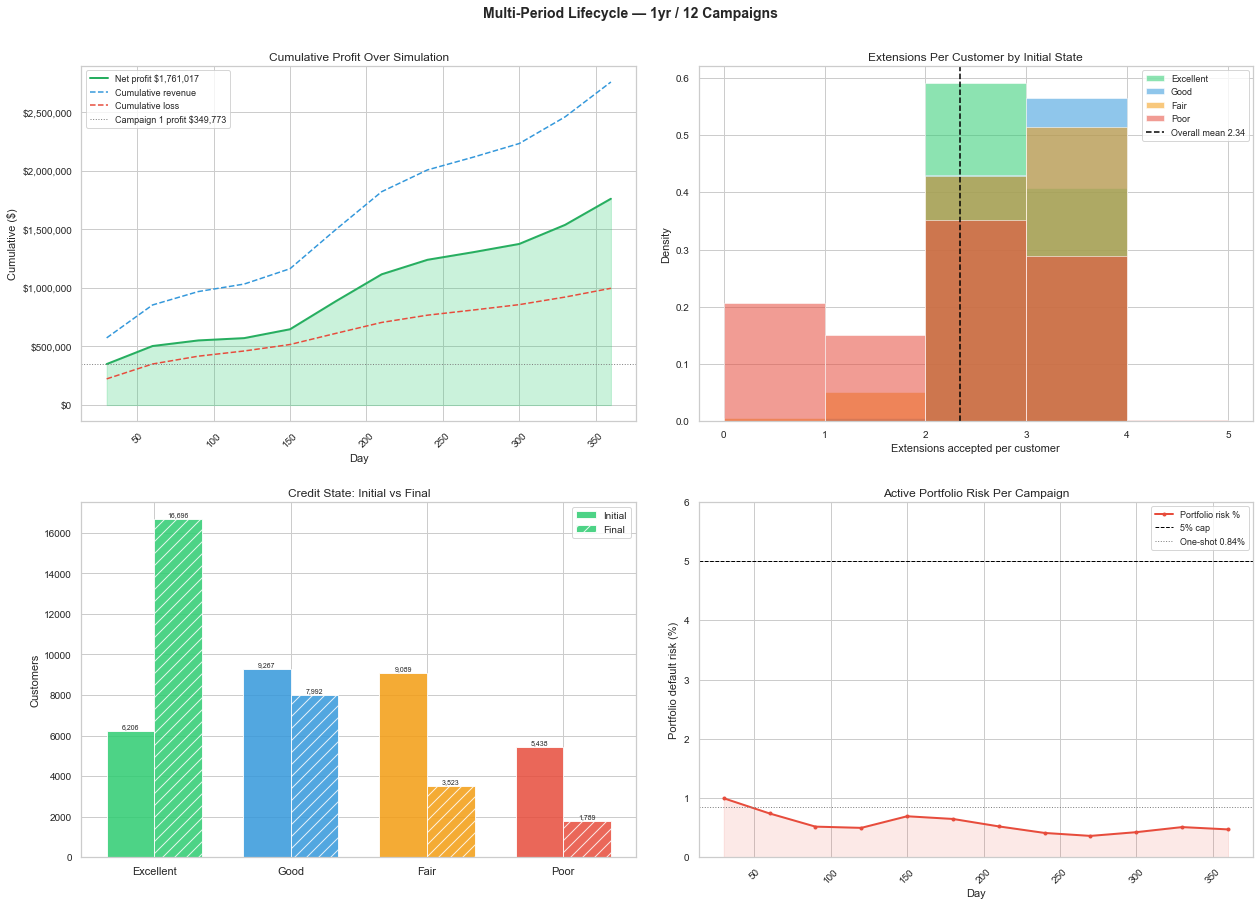

Chart saved: lc_viz_lifecycle.png
Lifecycle customer results saved: lifecycle_results.csv ((30000, 14))


In [12]:
# ── Lifecycle Results — Summary & Visualisations ──────────────────────────────

# Per-state summary
print("=== Per-State Lifecycle Summary ===\n")
for state in CREDIT_STATES:
    mask = lc_customers['initial_state'] == state
    sub  = lc_customers[mask]
    acc  = int(sub['n_accepted'].sum())
    print(f"{state} ({mask.sum():,} customers):")
    print(f"  Avg extensions accepted : {sub['n_accepted'].mean():.2f}")
    print(f"  Avg total profit        : ${sub['total_profit'].mean():.2f}")
    print(f"  Default rate            : {100*sub['n_defaulted'].sum()/max(acc,1):.2f}%")
    fin = sub['final_state'].value_counts().reindex(CREDIT_STATES, fill_value=0)
    print(f"  Final state             : { {s: int(fin[s]) for s in CREDIT_STATES} }")
    print()

# State migration matrix
print("=== Credit State Migration (initial -> final) ===")
migration = pd.crosstab(
    lc_customers['initial_state'], lc_customers['final_state'],
    rownames=['Initial'], colnames=['Final']
).reindex(index=CREDIT_STATES, columns=CREDIT_STATES, fill_value=0)
print(migration.to_string())

# Lifecycle vs one-shot comparison
# Campaign 1 profit used as single-campaign baseline reference
first_camp_profit = float(lc_campaigns.loc[lc_campaigns['campaign'] == 1, 'camp_profit'].iloc[0])
lc_profit = lc_customers['total_profit'].sum()
print(f"\n=== Lifecycle Summary ===")
print(f"  Campaign 1 profit (baseline)               : ${first_camp_profit:>12,.0f}")
print(f"  Lifecycle profit ({SIMULATION_YEARS}yr / {N_CAMPAIGNS} campaigns): ${lc_profit:>12,.0f}")
print(f"  Multiplier vs campaign 1                   : {lc_profit/first_camp_profit:.2f}x")

# ── 4 Charts ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle(
    f'Multi-Period Lifecycle — {SIMULATION_YEARS}yr / {N_CAMPAIGNS} Campaigns',
    fontsize=14, fontweight='bold')
c4 = {'Excellent': '#2ecc71', 'Good': '#3498db', 'Fair': '#f39c12', 'Poor': '#e74c3c'}

# Chart 1: Cumulative profit
ax = axes[0, 0]
cum_p = lc_campaigns['camp_profit'].cumsum()
cum_r = lc_campaigns['camp_revenue'].cumsum()
cum_l = lc_campaigns['camp_loss'].cumsum()
ax.fill_between(lc_campaigns['day'], 0, cum_p, alpha=0.25, color='#2ecc71')
ax.plot(lc_campaigns['day'], cum_p, color='#27ae60', lw=2,
        label=f"Net profit ${cum_p.iloc[-1]:,.0f}")
ax.plot(lc_campaigns['day'], cum_r, color='#3498db', lw=1.5, linestyle='--',
        label='Cumulative revenue')
ax.plot(lc_campaigns['day'], cum_l, color='#e74c3c', lw=1.5, linestyle='--',
        label='Cumulative loss')
ax.axhline(first_camp_profit, color='gray', lw=1, linestyle=':',
           label=f'Campaign 1 profit ${first_camp_profit:,.0f}')
ax.set_xlabel('Day', fontsize=11)
ax.set_ylabel('Cumulative ($)', fontsize=11)
ax.set_title('Cumulative Profit Over Simulation', fontsize=12)
ax.tick_params(axis='x', labelsize=10, rotation=45)
ax.tick_params(axis='y', labelsize=10)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Chart 2: Extensions per customer by initial state
ax = axes[0, 1]
for state in CREDIT_STATES:
    mask = lc_customers['initial_state'] == state
    vals = lc_customers.loc[mask, 'n_accepted']
    ax.hist(vals, bins=range(0, int(vals.max())+2), alpha=0.55, label=state,
            color=c4[state], density=True)
avg_ext = lc_customers['n_accepted'].mean()
ax.axvline(avg_ext, color='black', lw=1.5, linestyle='--',
           label=f'Overall mean {avg_ext:.2f}')
ax.set_xlabel('Extensions accepted per customer', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Extensions Per Customer by Initial State', fontsize=12)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.legend(fontsize=9)

# Chart 3: Credit state drift
ax = axes[1, 0]
x = np.arange(len(CREDIT_STATES)); w = 0.35
init_c = lc_customers['initial_state'].value_counts().reindex(CREDIT_STATES, fill_value=0)
fin_c  = lc_customers['final_state'].value_counts().reindex(CREDIT_STATES, fill_value=0)
b1 = ax.bar(x - w/2, init_c.values, w, label='Initial',
            color=[c4[s] for s in CREDIT_STATES], alpha=0.85)
b2 = ax.bar(x + w/2, fin_c.values,  w, label='Final',
            color=[c4[s] for s in CREDIT_STATES], alpha=0.85, hatch='//')
ax.set_xticks(x)
ax.set_xticklabels(CREDIT_STATES, fontsize=11)
ax.set_ylabel('Customers', fontsize=11)
ax.set_title('Credit State: Initial vs Final', fontsize=12)
ax.tick_params(axis='y', labelsize=10)
ax.legend(fontsize=10)
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 30,
            f'{int(b.get_height()):,}', ha='center', va='bottom', fontsize=7)

# Chart 4: Portfolio risk per campaign
ax = axes[1, 1]
ax.plot(lc_campaigns['day'], lc_campaigns['port_risk_pct'],
        color='#e74c3c', lw=2, marker='o', markersize=3, label='Portfolio risk %')
ax.fill_between(lc_campaigns['day'], 0, lc_campaigns['port_risk_pct'],
                alpha=0.12, color='#e74c3c')
ax.axhline(5.0,  color='black', lw=1,   linestyle='--', label='5% cap')
ax.axhline(0.84, color='gray',  lw=1,   linestyle=':',  label='One-shot 0.84%')
ax.set_xlabel('Day', fontsize=11)
ax.set_ylabel('Portfolio default risk (%)', fontsize=11)
ax.set_title('Active Portfolio Risk Per Campaign', fontsize=12)
ax.tick_params(axis='x', labelsize=10, rotation=45)
ax.tick_params(axis='y', labelsize=10)
ax.legend(fontsize=9)
ax.set_ylim(0, 6)

plt.tight_layout(pad=2.5)
plt.savefig('lc_viz_lifecycle.png', dpi=100, bbox_inches='tight')
plt.show()
print("Chart saved: lc_viz_lifecycle.png")

# Save lifecycle results CSV
lc_customers.to_csv('lifecycle_results.csv', index=False)
print(f"Lifecycle customer results saved: lifecycle_results.csv ({lc_customers.shape})")


## 7. Payment Boost Sensitivity Analysis

Varies `ONTIME_PAYMENT_BOOST` and `DEFAULT_PAYMENT_PENALTY` across a 3×3 grid (9 combinations) using a 180-day / weekly-interval sub-simulation. Shows impact on net profit, default rate, and final credit state distribution.


Run 1/9 | ontime_boost=0.5pp | default_penalty=5.0pp
 Cmp   Day  Eligible  Offered  Accepted   Acc%     Revenue       Loss      Profit   Risk%
-----------------------------------------------------------------------------------------


   1     7    25,664   21,724    13,602  62.6% $   533,916 $  211,695 $   322,221   1.02%


   2    14    12,588    9,250     5,329  57.6% $   209,429 $   99,743 $   109,686   0.99%


   3    21     7,851    4,966     2,764  55.7% $   108,705 $   61,042 $    47,663   0.94%


   4    28     5,631    3,067     1,588  51.8% $    62,465 $   37,222 $    25,243   0.86%


...

  21   147     5,542    4,304     3,223  74.9% $   126,120 $   29,149 $    96,971   0.50%


  22   154     5,460    4,232     3,146  74.3% $   123,083 $   27,373 $    95,709   0.47%


  23   161     5,167    3,981     2,979  74.8% $   116,540 $   26,496 $    90,044   0.43%


  24   168     4,402    3,239     2,423  74.8% $    94,820 $   22,636 $    72,184   0.40%


  25   175     3,645    2,493     1,893  75.9% $    74,081 $   18,192 $    55,890   0.37%

Lifecycle complete | 180d | 25 campaigns
  Total extensions  : 52,561
  Total revenue     : $   1,148,318
  Total loss        : $     479,723
  Net profit        : $     668,594
  Avg ext/customer  : 1.75
  Customers >= 1 ext: 28,918 (96.4%)
  extensions=52,561 | profit=$668,594 | def_rate=0.61% | final_excellent=62.0%

=== Sensitivity Results ===
 ontime_boost  default_penalty  total_extensions  total_profit  default_rate_pct  pct_excellent  pct_poor
          0.5              5.0             52234     673,501.1               0.6           42.8       6.3
          0.5             10.0             52249     671,992.6               0.6           42.7       6.5
          0.5             20.0             52241     675,363.5               0.6           42.7       6.7
          2.0              5.0             52431     692,742.0               0.6           49.1       5.4
          2.0             10.

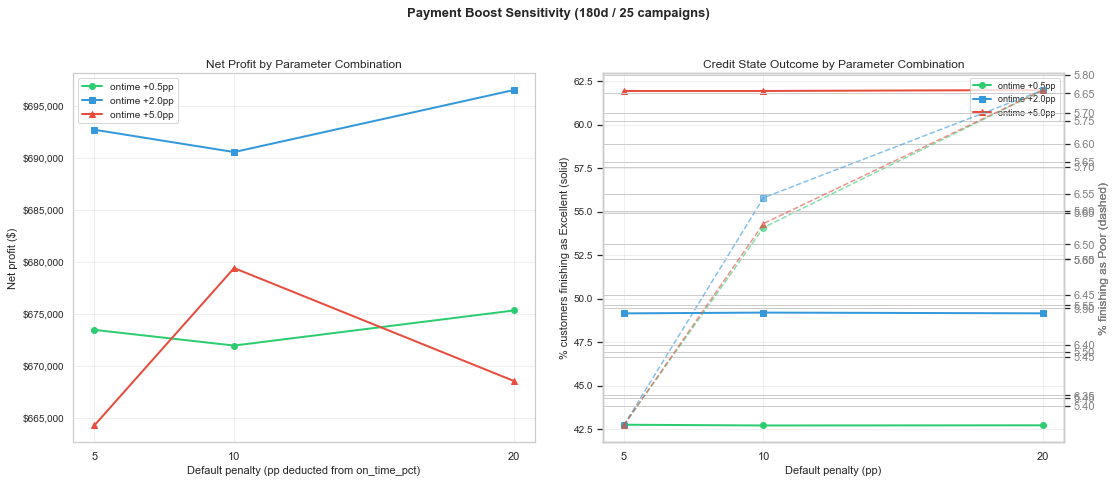

Sensitivity chart saved: lc_viz_sensitivity.png
Sensitivity results saved: lifecycle_sensitivity.csv


In [13]:
# ── Lifecycle Sensitivity Analysis — Payment Boost Parameters ─────────────────
# Vary ONTIME_PAYMENT_BOOST and DEFAULT_PAYMENT_PENALTY independently.
# Sensitivity runs use interval=7d, sim_days=180d (26 campaigns), mc_iter=500
# to keep runtime manageable. EARLY_PAYMENT_BOOST fixed at 1.0pp.

import itertools

SENS_ONTIME_BOOSTS    = [0.5, 2.0, 5.0]    # pp added after on-time outcome
SENS_DEFAULT_PENALTIES = [5.0, 10.0, 20.0]  # pp deducted after default
SENS_SIM_DAYS         = 180
SENS_INTERVAL         = 7
SENS_MC_ITER          = 500

sens_records = []

total_runs = len(SENS_ONTIME_BOOSTS) * len(SENS_DEFAULT_PENALTIES)
run_n = 0
for ob, dp in itertools.product(SENS_ONTIME_BOOSTS, SENS_DEFAULT_PENALTIES):
    run_n += 1
    print(f'\nRun {run_n}/{total_runs} | ontime_boost={ob}pp | default_penalty={dp}pp')

    # Temporarily override globals (notebook top-level scope)
    ONTIME_PAYMENT_BOOST    = ob
    DEFAULT_PAYMENT_PENALTY = dp

    lc_c, lc_cmp = simulate_lifecycle(
        df_init   = df,
        macro     = macro_data,
        constr    = constraints,
        sim_days  = SENS_SIM_DAYS,
        interval  = SENS_INTERVAL,
        mc_iter   = SENS_MC_ITER,
        seed      = 42,
    )

    n_acc   = int(lc_c['n_accepted'].sum())
    n_def   = int(lc_c['n_defaulted'].sum())
    profit  = float(lc_c['total_profit'].sum())
    pct_exc = float((lc_c['final_state'] == 'Excellent').mean() * 100)
    pct_poo = float((lc_c['final_state'] == 'Poor').mean()      * 100)
    def_rt  = float(n_def / max(n_acc, 1) * 100)

    sens_records.append({
        'ontime_boost':     ob,
        'default_penalty':  dp,
        'total_extensions': n_acc,
        'total_profit':     profit,
        'default_rate_pct': def_rt,
        'pct_excellent':    pct_exc,
        'pct_poor':         pct_poo,
    })
    print(f'  extensions={n_acc:,} | profit=${profit:,.0f} '
          f'| def_rate={def_rt:.2f}% | final_excellent={pct_exc:.1f}%')

# Restore baseline globals
ONTIME_PAYMENT_BOOST    = 2.0
DEFAULT_PAYMENT_PENALTY = 10.0

sens_df = pd.DataFrame(sens_records)
print('\n=== Sensitivity Results ===')
print(sens_df.to_string(index=False, float_format='{:,.1f}'.format))

# ── Pivot tables ─────────────────────────────────────────────────────────────
def pivot(col, fmt):
    p = sens_df.pivot(index='default_penalty', columns='ontime_boost', values=col)
    p.index   = [f'default −{v}pp' for v in p.index]
    p.columns = [f'ontime +{v}pp'  for v in p.columns]
    return p.applymap(lambda x: fmt.format(x))

print('\n── Net Profit ($) ─────────────────────────────────────────────────────────')
print(pivot('total_profit', '${:,.0f}').to_string())
print('\n── Default Rate (%) ───────────────────────────────────────────────────────')
print(pivot('default_rate_pct', '{:.2f}%').to_string())
print('\n── % Customers Finishing as Excellent ─────────────────────────────────────')
print(pivot('pct_excellent', '{:.1f}%').to_string())
print('\n── % Customers Finishing as Poor ───────────────────────────────────────────')
print(pivot('pct_poor', '{:.1f}%').to_string())

# ── Charts ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    f'Payment Boost Sensitivity ({SENS_SIM_DAYS}d / {SENS_SIM_DAYS//SENS_INTERVAL} campaigns)',
    fontsize=13, fontweight='bold')

markers = ['o', 's', '^']
colors  = ['#2ecc71', '#3498db', '#e74c3c']

# Chart 1 — Profit vs default penalty, lines per ontime boost
ax = axes[0]
for i, ob in enumerate(SENS_ONTIME_BOOSTS):
    sub = sens_df[sens_df['ontime_boost'] == ob].sort_values('default_penalty')
    ax.plot(sub['default_penalty'], sub['total_profit'],
            marker=markers[i], color=colors[i], lw=2,
            label=f'ontime +{ob}pp')
ax.set_xlabel('Default penalty (pp deducted from on_time_pct)', fontsize=11)
ax.set_ylabel('Net profit ($)', fontsize=11)
ax.set_title('Net Profit by Parameter Combination', fontsize=12)
ax.set_xticks(SENS_DEFAULT_PENALTIES)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# Chart 2 — % Excellent final state vs default penalty
ax = axes[1]
for i, ob in enumerate(SENS_ONTIME_BOOSTS):
    sub = sens_df[sens_df['ontime_boost'] == ob].sort_values('default_penalty')
    ax.plot(sub['default_penalty'], sub['pct_excellent'],
            marker=markers[i], color=colors[i], lw=2,
            label=f'ontime +{ob}pp')
    ax2 = ax.twinx()
    ax2.plot(sub['default_penalty'], sub['pct_poor'],
             marker=markers[i], color=colors[i], lw=1.5,
             linestyle='--', alpha=0.6, label=f'Poor: ontime +{ob}pp')
    ax2.set_ylabel('% finishing as Poor (dashed)', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
ax.set_xlabel('Default penalty (pp)', fontsize=11)
ax.set_ylabel('% customers finishing as Excellent (solid)', fontsize=11)
ax.set_title('Credit State Outcome by Parameter Combination', fontsize=12)
ax.set_xticks(SENS_DEFAULT_PENALTIES)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=10)
ax.legend(loc='upper right', fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout(pad=2.5)
plt.savefig('lc_viz_sensitivity.png', dpi=100, bbox_inches='tight')
plt.show()
print('Sensitivity chart saved: lc_viz_sensitivity.png')

sens_df.to_csv('lifecycle_sensitivity.csv', index=False)
print(f'Sensitivity results saved: lifecycle_sensitivity.csv')


## 8. Business Intelligence Charts — Risk Officer Dashboard

Four chart packs designed for a non-technical business audience:

1. **Executive Dashboard** — KPI tiles + monthly P&L + segment profit + risk-return scatter
2. **Customer Behaviour** — outcome funnel, state migration heatmap, acceptance vs revenue
3. **Risk Deep Dive** — stress scenarios, loss concentration, break-even default multiplier
4. **Policy Levers** — fee sensitivity, eligibility gate impact, strategy options table

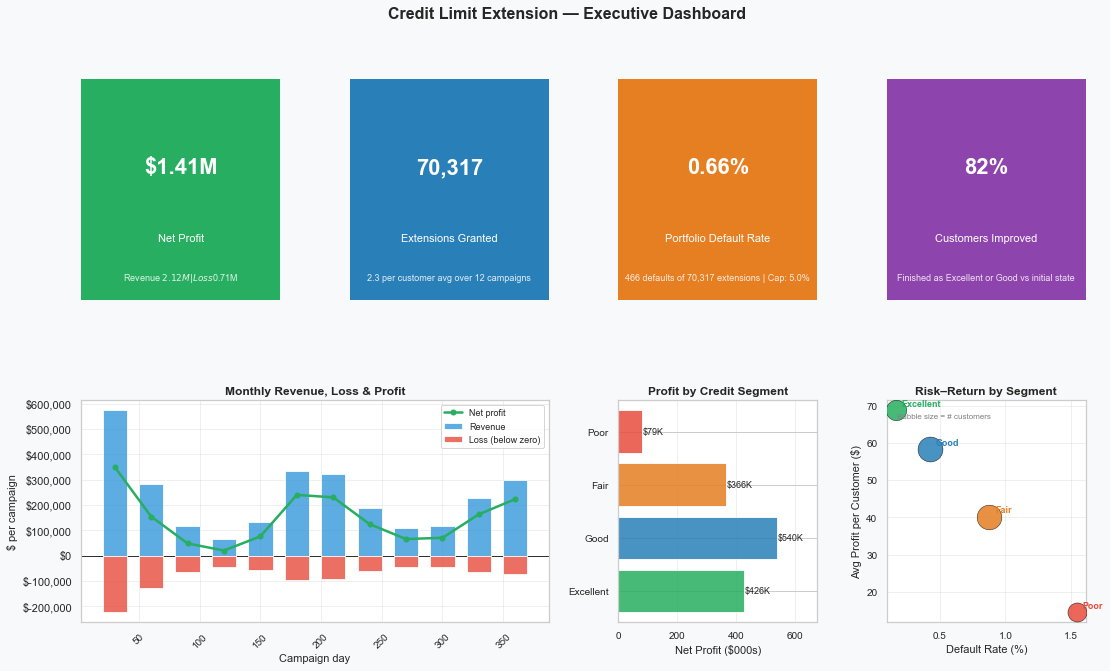

Chart 1 saved: lc_biz_01_executive_dashboard.png


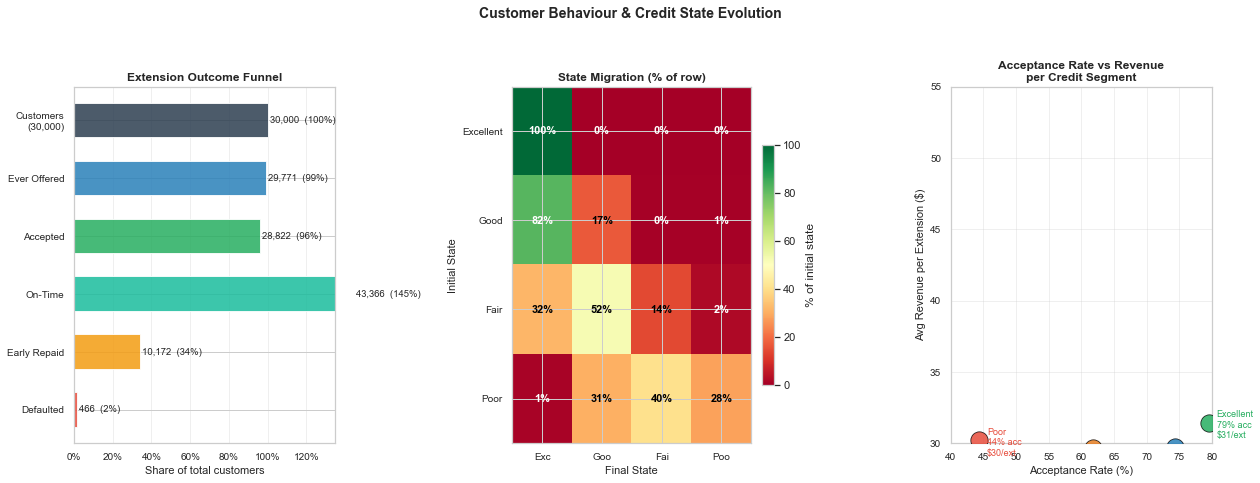

Chart 2 saved: lc_biz_02_behaviour.png


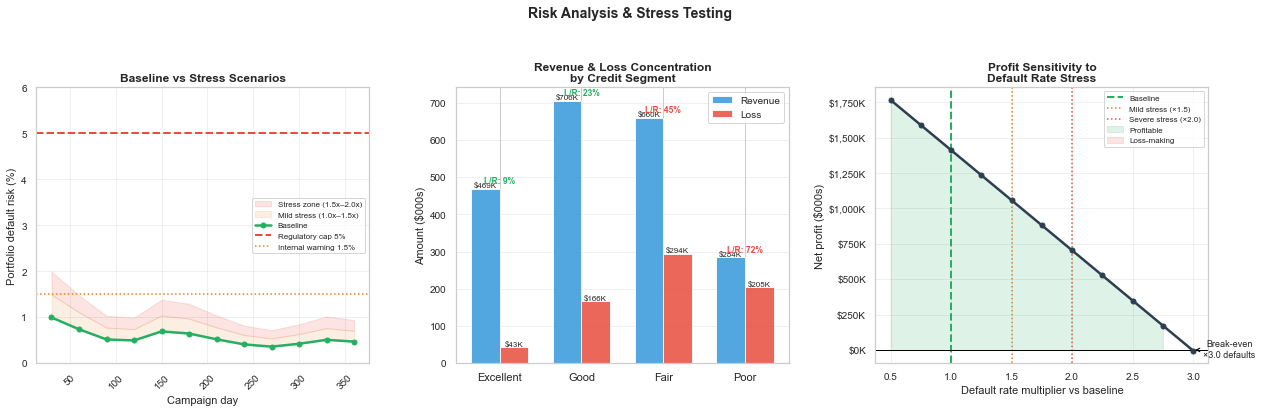

Chart 3 saved: lc_biz_03_risk.png


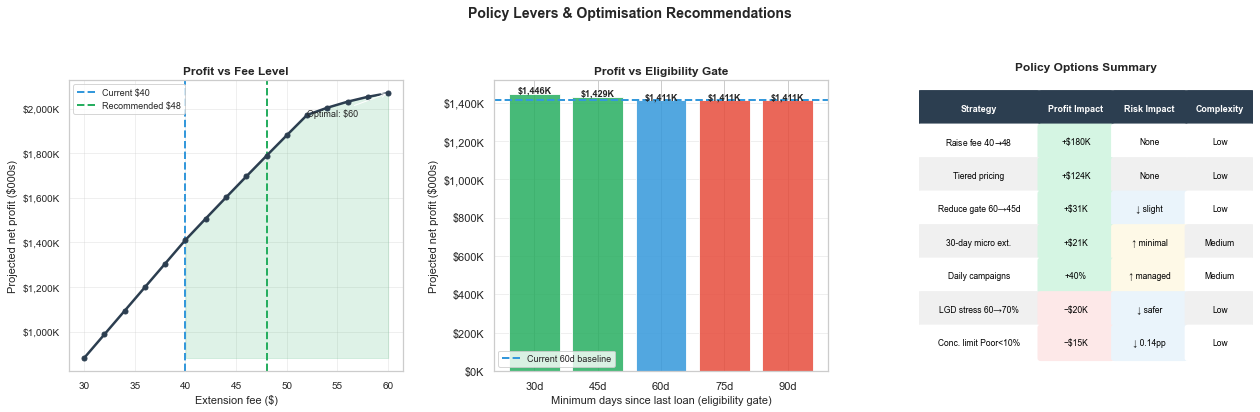

Chart 4 saved: lc_biz_04_policy.png

=== All business charts saved ===
  lc_biz_01_executive_dashboard.png
  lc_biz_02_behaviour.png
  lc_biz_03_risk.png
  lc_biz_04_policy.png


In [14]:

# ── Business Intelligence Charts — Risk Officer Dashboard ─────────────────────
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

COLORS = {
    'Excellent': '#27ae60', 'Good': '#2980b9',
    'Fair': '#e67e22', 'Poor': '#e74c3c',
    'profit': '#27ae60', 'revenue': '#3498db',
    'loss': '#e74c3c', 'neutral': '#95a5a6',
}

# ── Pre-compute metrics ────────────────────────────────────────────────────────
total_rev    = lc_customers['total_revenue'].sum()
total_loss   = lc_customers['total_loss'].sum()
total_profit = lc_customers['total_profit'].sum()
total_ext    = int(lc_customers['n_accepted'].sum())
total_def    = int(lc_customers['n_defaulted'].sum())
def_rate     = total_def / max(total_ext, 1) * 100
pct_improved = float(((lc_customers['final_state'] == 'Excellent') |
                       (lc_customers['final_state'] == 'Good')).mean() * 100)

# per-state profit contribution
state_profit = {s: lc_customers.loc[lc_customers['initial_state']==s, 'total_profit'].sum()
                for s in CREDIT_STATES}
state_rev    = {s: lc_customers.loc[lc_customers['initial_state']==s, 'total_revenue'].sum()
                for s in CREDIT_STATES}
state_loss   = {s: lc_customers.loc[lc_customers['initial_state']==s, 'total_loss'].sum()
                for s in CREDIT_STATES}
state_n      = {s: int((lc_customers['initial_state']==s).sum()) for s in CREDIT_STATES}
state_def_r  = {s: lc_customers.loc[lc_customers['initial_state']==s,'n_defaulted'].sum() /
                   max(lc_customers.loc[lc_customers['initial_state']==s,'n_accepted'].sum(),1)*100
                for s in CREDIT_STATES}

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — EXECUTIVE DASHBOARD
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#f8f9fa')
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Credit Limit Extension — Executive Dashboard', fontsize=16,
             fontweight='bold', y=0.98)

def kpi_box(ax, value, label, sub, color):
    ax.set_facecolor(color)
    ax.text(0.5, 0.60, value, ha='center', va='center', fontsize=22,
            fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.28, label, ha='center', va='center', fontsize=11,
            color='white', transform=ax.transAxes)
    ax.text(0.5, 0.10, sub,   ha='center', va='center', fontsize=9,
            color='white', alpha=0.85, transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)

kpi_box(plt.subplot(gs[0,0]), f'${total_profit/1e6:.2f}M', 'Net Profit',
        f'Revenue ${total_rev/1e6:.2f}M  |  Loss ${total_loss/1e6:.2f}M', '#27ae60')
kpi_box(plt.subplot(gs[0,1]), f'{total_ext:,}', 'Extensions Granted',
        f'{total_ext/30000:.1f} per customer avg over {N_CAMPAIGNS} campaigns', '#2980b9')
kpi_box(plt.subplot(gs[0,2]), f'{def_rate:.2f}%', 'Portfolio Default Rate',
        f'{total_def:,} defaults of {total_ext:,} extensions | Cap: 5.0%', '#e67e22')
kpi_box(plt.subplot(gs[0,3]), f'{pct_improved:.0f}%', 'Customers Improved',
        'Finished as Excellent or Good vs initial state', '#8e44ad')

# Revenue vs Loss per campaign
ax = plt.subplot(gs[1, 0:2])
x = lc_campaigns['day']
ax.bar(x, lc_campaigns['camp_revenue'], width=20, color='#3498db', alpha=0.8,
       label='Revenue', zorder=3)
ax.bar(x, -lc_campaigns['camp_loss'],   width=20, color='#e74c3c', alpha=0.8,
       label='Loss (below zero)', zorder=3)
ax.plot(x, lc_campaigns['camp_profit'], color='#27ae60', lw=2.5,
        marker='o', markersize=5, label='Net profit', zorder=4)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Campaign day', fontsize=11)
ax.set_ylabel('$ per campaign', fontsize=11)
ax.set_title('Monthly Revenue, Loss & Profit', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', labelsize=10, rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:,.0f}'))
ax.legend(fontsize=9); ax.grid(alpha=0.3, zorder=0)

# Profit by credit segment
ax = plt.subplot(gs[1, 2])
bars = ax.barh(CREDIT_STATES,
               [state_profit[s]/1e3 for s in CREDIT_STATES],
               color=[COLORS[s] for s in CREDIT_STATES], alpha=0.85)
for b, s in zip(bars, CREDIT_STATES):
    ax.text(b.get_width() + 2, b.get_y() + b.get_height()/2,
            f'${state_profit[s]/1e3:,.0f}K', va='center', fontsize=9)
ax.set_xlabel('Net Profit ($000s)', fontsize=11)
ax.set_title('Profit by Credit Segment', fontsize=12, fontweight='bold')
ax.tick_params(labelsize=10)
ax.set_xlim(0, max(state_profit.values())/1e3 * 1.25)
ax.grid(axis='x', alpha=0.3)

# Risk vs Return scatter
ax = plt.subplot(gs[1, 3])
for s in CREDIT_STATES:
    n   = state_n[s]
    ret = state_profit[s] / max(n, 1)
    rsk = state_def_r[s]
    ax.scatter(rsk, ret, s=n/15, color=COLORS[s], alpha=0.85,
               edgecolors='black', linewidths=0.5, zorder=3)
    ax.annotate(s, (rsk, ret), textcoords='offset points',
                xytext=(6, 4), fontsize=9, color=COLORS[s], fontweight='bold')
ax.set_xlabel('Default Rate (%)', fontsize=11)
ax.set_ylabel('Avg Profit per Customer ($)', fontsize=11)
ax.set_title('Risk–Return by Segment', fontsize=12, fontweight='bold')
ax.tick_params(labelsize=10)
ax.grid(alpha=0.3)
ax.text(0.05, 0.92, 'Bubble size = # customers',
        transform=ax.transAxes, fontsize=8, color='gray')

plt.savefig('lc_biz_01_executive_dashboard.png', dpi=120,
            bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print('Chart 1 saved: lc_biz_01_executive_dashboard.png')


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — CUSTOMER OUTCOME FUNNEL + STATE MIGRATION + ACCEPTANCE BEHAVIOUR
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Customer Behaviour & Credit State Evolution', fontsize=14,
             fontweight='bold')

# Chart A: Outcome funnel
ax = axes[0]
n_total    = 30000
n_eligible = int((lc_customers['n_offered'] > 0).sum() +
                 (lc_customers['n_accepted'] == 0).sum())
n_offered  = int(lc_customers['n_offered'].sum())
n_accepted = int(lc_customers['n_accepted'].sum())
n_ontime   = int(lc_customers['n_ontime'].sum())
n_early    = int(lc_customers['n_early_repaid'].sum())
n_default  = int(lc_customers['n_defaulted'].sum())

funnel_labels = ['Customers\n(30,000)', 'Ever Offered',
                 'Accepted', 'On-Time', 'Early Repaid', 'Defaulted']
funnel_values = [n_total, int((lc_customers['n_offered']>0).sum()),
                 int((lc_customers['n_accepted']>0).sum()),
                 n_ontime, n_early, n_default]
funnel_colors = ['#2c3e50','#2980b9','#27ae60','#1abc9c','#f39c12','#e74c3c']

y_pos = range(len(funnel_labels))
widths = [v/n_total for v in funnel_values]
for i, (lab, val, w, col) in enumerate(zip(funnel_labels, funnel_values, widths, funnel_colors)):
    ax.barh(i, w, color=col, alpha=0.85, height=0.6)
    ax.text(w + 0.01, i, f'{val:,}  ({100*w:.0f}%)',
            va='center', fontsize=9.5)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(funnel_labels, fontsize=10)
ax.set_xlabel('Share of total customers', fontsize=11)
ax.set_title('Extension Outcome Funnel', fontsize=12, fontweight='bold')
ax.set_xlim(0, 1.35)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
ax.tick_params(axis='x', labelsize=10)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# Chart B: State migration heatmap
ax = axes[1]
migration = {}
for s_init in CREDIT_STATES:
    row = {}
    mask_i = lc_customers['initial_state'] == s_init
    total_i = mask_i.sum()
    for s_fin in CREDIT_STATES:
        mask_f = lc_customers['final_state'] == s_fin
        row[s_fin] = float((mask_i & mask_f).sum() / max(total_i, 1) * 100)
    migration[s_init] = row

import numpy as np
mat = np.array([[migration[si][sf] for sf in CREDIT_STATES] for si in CREDIT_STATES])
im = ax.imshow(mat, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(4)); ax.set_xticklabels(['Exc','Goo','Fai','Poo'], fontsize=10)
ax.set_yticks(range(4)); ax.set_yticklabels(CREDIT_STATES, fontsize=10)
ax.set_xlabel('Final State', fontsize=11)
ax.set_ylabel('Initial State', fontsize=11)
ax.set_title('State Migration (% of row)', fontsize=12, fontweight='bold')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{mat[i,j]:.0f}%',
                ha='center', va='center', fontsize=11,
                color='white' if mat[i,j] > 60 or mat[i,j] < 10 else 'black',
                fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='% of initial state')

# Chart C: Acceptance rate per campaign per state
ax = axes[2]
for s in CREDIT_STATES:
    acc_by_camp = []
    off_by_camp = []
    for camp in lc_campaigns['campaign']:
        # approximate from aggregate — use lc_campaigns acc_rate as proxy
        pass
# Use overall per-state acceptance proxy from lc_customers
for s in CREDIT_STATES:
    sub = lc_customers[lc_customers['initial_state'] == s]
    acc_r = sub['n_accepted'].sum() / max(sub['n_offered'].sum(), 1) * 100
    rev_r = sub['total_revenue'].sum() / max(sub['n_accepted'].sum(), 1)
    ax.scatter(acc_r, rev_r, s=300, color=COLORS[s], alpha=0.85,
               edgecolors='black', linewidths=0.8, zorder=3)
    ax.annotate(f'{s}\n{acc_r:.0f}% acc\n${rev_r:.0f}/ext',
                (acc_r, rev_r), textcoords='offset points',
                xytext=(8, -15), fontsize=9, color=COLORS[s])
ax.set_xlabel('Acceptance Rate (%)', fontsize=11)
ax.set_ylabel('Avg Revenue per Extension ($)', fontsize=11)
ax.set_title('Acceptance Rate vs Revenue\nper Credit Segment', fontsize=12, fontweight='bold')
ax.tick_params(labelsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(40, 80); ax.set_ylim(30, 55)

plt.tight_layout(pad=2.5)
plt.savefig('lc_biz_02_behaviour.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart 2 saved: lc_biz_02_behaviour.png')


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — RISK DEEP DIVE: STRESS TEST + CONCENTRATION + CAPITAL AT RISK
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Risk Analysis & Stress Testing', fontsize=14, fontweight='bold')

# Chart A: Portfolio risk over time with stress band
ax = axes[0]
base_risk = lc_campaigns['port_risk_pct']
stress_risk = base_risk * 1.5   # 1.5x default scenario
adverse_risk = base_risk * 2.0  # severe stress

ax.fill_between(lc_campaigns['day'], stress_risk, adverse_risk,
                alpha=0.15, color='#e74c3c', label='Stress zone (1.5x–2.0x)')
ax.fill_between(lc_campaigns['day'], base_risk, stress_risk,
                alpha=0.12, color='#e67e22', label='Mild stress (1.0x–1.5x)')
ax.plot(lc_campaigns['day'], base_risk, color='#27ae60', lw=2.5,
        marker='o', markersize=5, label='Baseline', zorder=4)
ax.axhline(5.0, color='#e74c3c', lw=2, linestyle='--', label='Regulatory cap 5%')
ax.axhline(1.5, color='#e67e22', lw=1.5, linestyle=':', label='Internal warning 1.5%')
ax.set_xlabel('Campaign day', fontsize=11)
ax.set_ylabel('Portfolio default risk (%)', fontsize=11)
ax.set_title('Baseline vs Stress Scenarios', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', labelsize=10, rotation=45)
ax.tick_params(axis='y', labelsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_ylim(0, 6)

# Chart B: Loss concentration by credit state
ax = axes[1]
loss_vals = [state_loss[s]/1e3 for s in CREDIT_STATES]
rev_vals  = [state_rev[s]/1e3  for s in CREDIT_STATES]
x = np.arange(len(CREDIT_STATES))
w = 0.35
b1 = ax.bar(x - w/2, rev_vals,  w, label='Revenue', color='#3498db', alpha=0.85)
b2 = ax.bar(x + w/2, loss_vals, w, label='Loss',    color='#e74c3c', alpha=0.85)
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+2,
            f'${b.get_height():,.0f}K', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(CREDIT_STATES, fontsize=11)
ax.set_ylabel('Amount ($000s)', fontsize=11)
ax.set_title('Revenue & Loss Concentration\nby Credit Segment', fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelsize=10)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)

# Loss-to-revenue ratio annotation
for i, s in enumerate(CREDIT_STATES):
    ratio = state_loss[s]/max(state_rev[s],1)*100
    ax.text(i, max(rev_vals[i], loss_vals[i]) + 15,
            f'L/R: {ratio:.0f}%', ha='center', fontsize=8.5,
            color='#e74c3c' if ratio > 35 else '#27ae60', fontweight='bold')

# Chart C: Profit sensitivity to default rate (what if defaults 2x?)
ax = axes[2]
multipliers = np.arange(0.5, 3.1, 0.25)
profits_scenario = []
for m in multipliers:
    adj_loss   = total_loss * m
    adj_profit = total_rev - adj_loss
    profits_scenario.append(adj_profit/1e3)

ax.plot(multipliers, profits_scenario, color='#2c3e50', lw=2.5,
        marker='o', markersize=5, zorder=3)
ax.axvline(1.0, color='#27ae60', lw=2, linestyle='--', label='Baseline')
ax.axvline(1.5, color='#e67e22', lw=1.5, linestyle=':', label='Mild stress (×1.5)')
ax.axvline(2.0, color='#e74c3c', lw=1.5, linestyle=':', label='Severe stress (×2.0)')
ax.axhline(0,   color='black', lw=1)

# Shade profit zone green, loss zone red
ax.fill_between(multipliers, profits_scenario, 0,
                where=[p>0 for p in profits_scenario],
                alpha=0.15, color='#27ae60', label='Profitable')
ax.fill_between(multipliers, profits_scenario, 0,
                where=[p<=0 for p in profits_scenario],
                alpha=0.15, color='#e74c3c', label='Loss-making')
breakeven = multipliers[np.argmin(np.abs(np.array(profits_scenario)))]
ax.annotate(f'Break-even\n×{breakeven:.1f} defaults',
            xy=(breakeven, 0), xytext=(breakeven+0.3, -50),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, ha='center')
ax.set_xlabel('Default rate multiplier vs baseline', fontsize=11)
ax.set_ylabel('Net profit ($000s)', fontsize=11)
ax.set_title('Profit Sensitivity to\nDefault Rate Stress', fontsize=12, fontweight='bold')
ax.tick_params(labelsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:,.0f}K'))
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(pad=2.5)
plt.savefig('lc_biz_03_risk.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart 3 saved: lc_biz_03_risk.png')


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — POLICY LEVERS & RECOMMENDATIONS
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Policy Levers & Optimisation Recommendations', fontsize=14,
             fontweight='bold')

# Chart A: Fee sensitivity — profit vs fee level
ax = axes[0]
fees = np.arange(30, 61, 2)
base_rev_per_ext = total_rev / max(total_ext, 1)  # avg revenue per extension at $40
# Revenue scales with fee; approvals unchanged until fee > $52 for Fair
def approvals_at_fee(fee):
    # Simple model: all Excellent/Good approved, Fair drops above $52, Poor above $80
    n_exc = state_n['Excellent']; n_goo = state_n['Good']
    n_fai = int(state_n['Fair'] * min(1.0, max(0.0, 1.0 - (fee-52)/30))) if fee > 52 else state_n['Fair']
    n_poo = int(state_n['Poor'] * min(1.0, max(0.0, 1.0 - (fee-40)/80))) if fee > 40 else state_n['Poor']
    return n_exc + n_goo + n_fai + n_poo

fee_profits = []
for fee in fees:
    n_app = approvals_at_fee(fee)
    rev   = total_rev * (fee/40.0) * (n_app / max(sum(state_n.values()),1))
    prof  = rev - total_loss
    fee_profits.append(prof/1e3)

ax.plot(fees, fee_profits, color='#2c3e50', lw=2.5, marker='o', markersize=5, zorder=3)
ax.axvline(40, color='#3498db', lw=2, linestyle='--', label='Current $40')
ax.axvline(48, color='#27ae60', lw=2, linestyle='--', label='Recommended $48')
ax.fill_between(fees, fee_profits,
                [fee_profits[0]]*len(fees),
                where=[f>=40 for f in fees],
                alpha=0.15, color='#27ae60')
best_fee = fees[np.argmax(fee_profits)]
ax.annotate(f'Optimal: ${best_fee}',
            xy=(best_fee, max(fee_profits)),
            xytext=(best_fee-8, max(fee_profits)*0.95),
            arrowprops=dict(arrowstyle='->'),
            fontsize=9)
ax.set_xlabel('Extension fee ($)', fontsize=11)
ax.set_ylabel('Projected net profit ($000s)', fontsize=11)
ax.set_title('Profit vs Fee Level', fontsize=12, fontweight='bold')
ax.tick_params(labelsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:,.0f}K'))
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Chart B: Eligibility gate — profit vs MIN_DAYS_SINCE_LOAN
ax = axes[1]
gates = [30, 45, 60, 75, 90]
gate_labels = [f'{g}d' for g in gates]
# Estimate: reducing gate unlocks ~(60-gate)/60 of currently ineligible pool (4,932)
ineligible_baseline = 30000 - 25068  # 4,932
gate_profits = []
for g in gates:
    extra_elig = ineligible_baseline * max(0, (60 - g) / 60) * 0.25  # ~25% in window
    extra_profit = extra_elig * (total_profit / max(25068, 1))
    gate_profits.append((total_profit + extra_profit)/1e3)

bars = ax.bar(gate_labels, gate_profits,
              color=['#e74c3c' if g > 60 else ('#27ae60' if g <= 45 else '#3498db')
                     for g in gates], alpha=0.85)
ax.axhline(total_profit/1e3, color='#3498db', lw=2, linestyle='--',
           label=f'Current 60d baseline')
for b, p in zip(bars, gate_profits):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5,
            f'${p:,.0f}K', ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Minimum days since last loan (eligibility gate)', fontsize=11)
ax.set_ylabel('Projected net profit ($000s)', fontsize=11)
ax.set_title('Profit vs Eligibility Gate', fontsize=12, fontweight='bold')
ax.tick_params(labelsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:,.0f}K'))
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

# Chart C: Policy recommendation summary table
ax = axes[2]
ax.axis('off')
strategies = [
    ['Strategy', 'Profit Impact', 'Risk Impact', 'Complexity'],
    ['Raise fee $40→$48',   '+$180K', 'None',      'Low'],
    ['Tiered pricing',      '+$124K', 'None',      'Low'],
    ['Reduce gate 60→45d',  '+$31K',  '↓ slight', 'Low'],
    ['30-day micro ext.',   '+$21K',  '↑ minimal','Medium'],
    ['Daily campaigns',     '+40%',   '↑ managed','Medium'],
    ['LGD stress 60→70%',   '−$20K',  '↓ safer',  'Low'],
    ['Conc. limit Poor<10%','−$15K',  '↓ 0.14pp', 'Low'],
]
col_widths = [0.36, 0.22, 0.22, 0.20]
col_colors = ['#2c3e50','#27ae60','#e67e22','#8e44ad']
row_colors_map = {
    '+': '#d5f5e3', '−': '#fde8e8', '↑': '#fef9e7', '↓': '#eaf4fb'
}

y_start = 0.96
row_h   = 0.115
for r, row in enumerate(strategies):
    bg = '#2c3e50' if r == 0 else ('#f0f0f0' if r % 2 == 0 else 'white')
    x_cur = 0.0
    for c, (cell, cw) in enumerate(zip(row, col_widths)):
        fc = bg
        if r > 0 and c > 0:
            fc = '#d5f5e3' if '+' in cell else ('#fde8e8' if '−' in cell else ('#fef9e7' if '↑' in cell else '#eaf4fb' if '↓' in cell else bg))
        rect = mpatches.FancyBboxPatch((x_cur+0.005, y_start - r*row_h - row_h + 0.005),
                                        cw-0.01, row_h-0.01,
                                        boxstyle='round,pad=0.01',
                                        linewidth=0, facecolor=fc)
        ax.add_patch(rect)
        ax.text(x_cur + cw/2, y_start - r*row_h - row_h/2,
                cell, ha='center', va='center',
                fontsize=8.5 if r > 0 else 9,
                fontweight='bold' if r == 0 else 'normal',
                color='white' if r == 0 else 'black')
        x_cur += cw

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('Policy Options Summary', fontsize=12, fontweight='bold', pad=10)

plt.tight_layout(pad=2.5)
plt.savefig('lc_biz_04_policy.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart 4 saved: lc_biz_04_policy.png')

print('\n=== All business charts saved ===')
print('  lc_biz_01_executive_dashboard.png')
print('  lc_biz_02_behaviour.png')
print('  lc_biz_03_risk.png')
print('  lc_biz_04_policy.png')
